# CILC method

After having implemented the ILC method properly and checking that it is not enough to extract the $\mu$-distorted $y$ signal, I am taking a step further by $\textit{constraining}$ the ILC method, so now I will proceed with the CILC method.

This code must

1. Calculate the covariance matrix: $$ \widehat{\mathbf{R}}_{ij}(\bar{\ell}) = \frac{1}{N_{\bar{\ell}}} \sum_{\bar{\ell} - \Delta \bar{\ell}}^{\bar{\ell} + \Delta \bar{\ell}} \sum_{m} x_{\ell m, i} x_{\ell m, j}^{*} , $$
where $N_{\ell} = (\ell + \Delta \ell + 1)^2 - (\ell - \Delta \ell)^2$.


2. Compute the transposed weights: $$\underline{\omega^t} = \frac{(\underline{b^t} \cdot \underline{\underline{\widehat{R}^{-1}}} \cdot \underline{b}) \cdot \underline{a^t} \cdot \underline{\underline{\widehat{R}^{-1}}} - (\underline{a^t} \cdot \underline{\underline{\widehat{R}^{-1}}} \cdot \underline{b}) \cdot \underline{b^t} \cdot \underline{\underline{\widehat{R}^{-1}}} }{ (\underline{a^t} \cdot {\underline{\underline{\widehat{R}^{-1}}}} \cdot \underline{a}) (\underline{b^t} \cdot \underline{\underline{\widehat{R}^{-1}}} \cdot \underline{b}) - (\underline{a^t} \cdot {\underline{\underline{\widehat{R}^{-1}}}} \cdot \underline{b})^2 } $$

3. Apply the weights ($\underline{\omega^t}$) to the data ($d_i$).

---
Shouldn't we transpose $\underline{\omega^t}$ in order to apply it to the weights?
---
---

4. Get the output: $$\hat{y} = \Sigma_i \left( \omega_i \cdot d_i (p) \right), $$
and multiply it by $\mu$.

5. Marginalise over the $\widehat{\mu y}$ tSZ signal so that:
$$ <\widehat{\mu y}>^2 \text{is minimum,}$$
$$ \tilde{\underline{w^t}} \cdot \underline{h} = 1,$$
$$ \tilde{\underline{w^t}} \cdot \underline{g} = 0.$$

### Previous

In [2]:
### IMPORT PACKAGES ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
import numba as nb
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import gc
import os
import math
from joblib import Parallel, delayed
from numba import njit, prange
from scipy.interpolate import *
from scipy import stats
from scipy import odr
from scipy.signal import windows

from astropy.wcs import WCS
from astropy.io import fits
from reproject import reproject_from_healpix

import datetime

print("Packages imported successfully")

Packages imported successfully


In [1]:
### MEMORY MANAGEMENT ###

import gc # Garbage Collector

# Before starting a new run, clear previous big variables if they exist
if 'data_cube' in locals():
    del data_cube
if 'alms_list' in locals():
    del alms_list
if 'y_hat_harmonic' in locals():
    del y_hat_harmonic
if 'y_hat_pixel' in locals():
    del y_hat_pixel
if 'muy_hat_harmonic' in locals():
    del muy_hat_harmonic
if 'muy_hat_pixel' in locals():
    del muy_hat_pixel
if 'residuals_harmonic' in locals():
    del residuals_harmonic
if 'residuals_pixel' in locals():
    del residuals_pixel
if 'stack_y_cilc_10e3' in locals():
    del stack_y_cilc_10e3
if 'stack_muy_cilc_10e3' in locals():
    del stack_muy_cilc_10e3
if 'stack_y_cilc_10e4' in locals():
    del stack_y_cilc_10e4
if 'stack_muy_cilc_10e4' in locals():
    del stack_muy_cilc_10e4
if 'stack_y_ilc_10e3' in locals():
    del stack_y_ilc_10e3
if 'stack_muy_ilc_10e3' in locals():
    del stack_muy_ilc_10e3
if 'stack_y_ilc_10e4' in locals():
    del stack_y_ilc_10e4
if 'stack_muy_ilc_10e4' in locals():
    del stack_muy_ilc_10e4
if 'stack_y_real_10e3' in locals():
    del stack_y_real_10e3
if 'stack_muy_real_10e3' in locals():
    del stack_muy_real_10e3
if 'stack_y_real_10e4' in locals():
    del stack_y_real_10e4
if 'stack_muy_real_10e4' in locals():
    del stack_muy_real_10e4


gc.collect() # Manually trigger memory cleanup

1769

### Check frequencies and mu value!

In [3]:
### DEFINITIONS: CONSTANTS, FREQUENCIES, ETC. ###

# Nside
nside_work = 2048

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# Zegeye paper frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270]

# Reference noise
base_sensitivity_uk_arcmin = 0.2

# Theoretical (LCDM) mu-distortion value
#mu = 2e-8
mu = 0

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

print("----------------------------------------")
print("------------ Configuration -------------")
print("----------------------------------------")
print(f"Nside: {nside_work}")
print(f"Frequencies (GHz): {zegeye_frequencies}")
print(rf"T_CMB in muK: {T_cmb_muK:.0f} muK")
print(f"Theoretical mu-distortion value: {mu:.0e}")
print(f"Base sensitivity: {base_sensitivity_uk_arcmin} uK-arcmin")
print(f"Pixel area at Nside {nside_work}: {pixel_area_arcmin2:.2f} arcmin^2")
print("----------------------------------------")
print("------- Date:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),"------")
print("----------------------------------------")

----------------------------------------
------------ Configuration -------------
----------------------------------------
Nside: 2048
Frequencies (GHz): [30, 40, 90, 150, 220, 270]
T_CMB in muK: 2725500 muK
Theoretical mu-distortion value: 0e+00
Base sensitivity: 0.2 uK-arcmin
Pixel area at Nside 2048: 2.95 arcmin^2
----------------------------------------
------- Date: 2026-05-15 10:32:12 ------
----------------------------------------


### Pipeline

In [4]:
### 1. Load the processed Maps and the data_cube_32 ###

path_to_websky = '/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/'
#data_cube_name = f"data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits"
data_cube_name = f"data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_2e-04.fits"
if not os.path.exists(path_to_websky + data_cube_name):
    print(f"Error: The file {data_cube_name} does not exist in the path {path_to_websky}. Please check the file name (and path).")

# A. Load the Data Cube (The 'Observed' (simulated) data)
data_cube = hp.read_map(path_to_websky + data_cube_name, field=None).astype(np.float32)
print(f"Loading the {data_cube_name} (4 layers: CMB + tSZ + noise + mu-distorted tSZ) from file...")

# B. Load the Truth Maps (For validation and residuals)
y_map = hp.read_map(path_to_websky + "y_map.fits").astype(np.float32)
muy_map = mu * y_map
cmb_map = hp.read_map(path_to_websky + "cmb_map.fits").astype(np.float32)
print("Loading the original y_map and cmb_map for validation...")

print(f"Data Cube loaded. Shape: {data_cube.shape}")
print(f"{data_cube.shape[0]} frequencies: {zegeye_frequencies} with 4 layer maps of {data_cube.shape[1]} pixels as Nside = {nside_work}.")
# Should be (9, 50331648) for Nside 2048

Loading the data_cube_32_6freq_0.2muK_2e-04.fits (4 layers: CMB + tSZ + noise + mu-distorted tSZ) from file...
Loading the original y_map and cmb_map for validation...
Data Cube loaded. Shape: (6, 50331648)
6 frequencies: [30, 40, 90, 150, 220, 270] with 4 layer maps of 50331648 pixels as Nside = 2048.


In [5]:
### 2. Define the tSZ frequency scaling function g(nu) and Taylor expansion h(nu) ###

def get_physics_constants(nu):
    """Calculate the physics constants needed for tSZ scaling."""
    T_cmb = 2.7255     # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency
    return x

def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4
    return g_nu

def get_tsz_h(nu):
    """Calculate the tSZ Taylor expansion frequency scaling h(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    h_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    return h_nu

## CILC

### Outline 

1. CILC method definition: Pixel CILC (P-CILC) & Harmonic CILC (H-CILC).

2. Processing for each signal:

| **Subsection** | __Signal__ | **SED** | **Extracted map** |
| :---: | :---: | :---: | :---: |
| 2.1. | tSZ | $g(\nu) = x \coth \left( \frac{x}{2} \right) - 4 $ | $y$-map |
| 2.2. | CMB | $a=[1,...,1]$ | $CMB$-map |
| 2.3. | $\mu$-distorted tSZ | $h(\nu) = - \frac{x}{2} \frac{1}{\sinh^2\left( \frac{x}{2} \right)}$ | $\mu y$-map |

3. Plotting two views for every map:
- Zoomed view.
- Mollweide view.

4. Extra plots.

5. TT map: $\mu y$ Vs. $y$ for $\mu$ extraction.

## 1. ILC

### 1.1. ILC method definition

In [6]:
def run_pixel_ilc(data_cube, vector_muK): ### UNITLESS MAP OUTPUT + WEIGHTS ###

    # C definition
    n_freq, n_pix = data_cube.shape
    C = (1.0 / n_pix) * (data_cube @ data_cube.T) # IS IT THAT d_i (p') * d_j (p') = data_cube @ data_cube.T
    C_inv = np.linalg.pinv(C)

    # Calculate the weights
    weights = (C_inv @ vector_muK) / (vector_muK.T @ C_inv @ vector_muK)

    return weights @ data_cube, weights

# weights @ data_cube IS UNITLESS AS [weights] = 1/g^t * data_cube = 1/T_cmb * T_cmb
# [g] = T_cmb_muK
# [data_cube] = T_cmb_muK

In [9]:
def run_harmonic_ilc_with_weights(data_cube, vector_muK, l_bins): ### UNITLESS MAP OUTPUT + WEIGHTS PER BIN  ###
    """Advanced Harmonic-Space ILC (Multi-scale)"""
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    lmax = 3*nside-1
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    ell, _ = hp.Alm.getlm(lmax)
    
    # NEW: Matrix to store weights for each bin
    weights_per_bin = []

    for i in range(len(l_bins)-1):
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        inv_cov = np.linalg.pinv(cov_bin)
        
        # Calculate weights for THIS specific scale
        w_bin = (inv_cov @ vector_muK) / (vector_muK.T @ inv_cov @ vector_muK)
        weights_per_bin.append(w_bin) # Store them
        
        final_alms[mask] = w_bin @ bin_alms
        
    return hp.alm2map(final_alms, nside=nside), np.array(weights_per_bin)

### 1.2. P-ILC implementation for later comparison

1.2.1. $y$-map

In [7]:
### Define the g_vector_muK ###

# Define g_vector (and h_vector) in muK units for the frequencies in the data cube
g_vector_muK = np.array([get_tsz_g(nu) for nu in zegeye_frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

# If we wanted to do the same for h_vector (for the mu distorted tSZ signal ILC), we would do:
#h_vector_muK = np.array([get_tsz_h(nu) for nu in zegeye_frequencies]) * T_cmb_muK

In [8]:
### Check lengths of the vectors and frequencies ###

print(len(g_vector_muK)) # Should be 9, one for each frequency
print(len(zegeye_frequencies)) # Should be 9, one for each frequency

6
6


In [9]:
### See the g_vector values for the frequencies ### 

print(g_vector_muK/T_cmb_muK) # Should be unitless and match the expected g(nu) values for the frequencies

[-1.9537051  -1.91799162 -1.59794759 -0.95332592  0.03829958  0.83696256]


In [10]:
### P-ILC ###

# Run P-ILC. The resulting map is unitless.
y_hat_pixel_ilc, w_pixel_y_ilc = run_pixel_ilc(data_cube, g_vector_muK)

# Calculate the residual in dimensionless y units (Truth - Reconstruction)
y_residual_pixel_ilc = y_map - y_hat_pixel_ilc

"""
# As y_map is also unitless, I will leave both unitless. However, I could aslo convert both to muK units and have a 10^5 scale factor.
y_map_muK = y_map * T_cmb_muK
y_residual_pixel_muK = y_map_muK - y_hat_pixel_ilc * T_cmb_muK
"""

# Validation: Both should be order 10^-5
print(f"Truth max: {np.max(y_map):.2e}")
print(f"Reco max: {np.max(y_hat_pixel_ilc):.2e}")
print(f"Residual max: {np.max(y_residual_pixel_ilc):.2e}")
print("WATCH!!! IS THERE A PROBLEM WITH RECO?")

KeyboardInterrupt: 

In [ ]:
### P-ILC WEIGHTS ANALYSIS ON THE tSZ SIGNAL ###

df_weights_pixel_ilc = pd.DataFrame({
    'Freq (GHz)': zegeye_frequencies,
    'Weight': w_pixel_y_ilc,
    'g(nu) * T_cmb_muK': g_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_ilc = df_weights_pixel_ilc.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("------------------------------")
print("--- P-ILC Analysis Weights ---")
print("------------------------------")
print(df_horizontal_pixel_ilc)

# Verify the constraint is satisfied
constraint_check_pixel_ilc = np.sum(w_pixel_y_ilc * g_vector_muK)
w_pixel_y_ilc_sum = np.sum(w_pixel_y_ilc)
print("------------------------------")
print(f"Constraint Check: {constraint_check_pixel_ilc:.4f}")
print(f"Sum of Weights: {w_pixel_y_ilc_sum:.4f}")
print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

------------------------------
--- P-ILC Analysis Weights ---
------------------------------
Freq (GHz)                  30            40            90            150           220           270
Weight            -1.201542e-07  5.329624e-08 -1.208518e-07  8.420580e-08 -4.369844e-08  1.472172e-07
g(nu) * T_cmb_muK -5.324823e+06 -5.227486e+06 -4.355206e+06 -2.598290e+06  1.043855e+05  2.281141e+06
------------------------------
Constraint Check: 1.0000
Sum of Weights: 0.0000
Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.


In [ ]:
### SAVE THE y P-ILC MAP and residual IN THE LOCAL DISK ###

hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/ILC_for_comparison/P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map.fits", y_hat_pixel_ilc, 
            coord='G', overwrite=True, dtype=np.float32)

hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/ILC_for_comparison/P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_residual_map.fits", y_residual_pixel_ilc, 
            coord='G', overwrite=True, dtype=np.float32)

print(f"ILC y_map (muK units) saved successfully as 'P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map.fits'.")
print(f"ILC residual map (muK units) saved successfully as 'P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_residual_map.fits'.")
print("---------------------------------")
print("--- y (hat) P-ILC Information ---")
print("---------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Map shape: {y_hat_pixel_ilc.shape}")
print(f"Map dtype: {y_hat_pixel_ilc.dtype}")
print(f"Map memory usage: {y_hat_pixel_ilc.nbytes / 1e6:.2f} MB")
print(f"Map frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("---------------------------------")

ILC y_map (muK units) saved successfully as 'P_ILC_6freq_0.2muK_y_map.fits'.
ILC residual map (muK units) saved successfully as 'P_ILC_6freq_0.2muK_y_residual_map.fits'.
---------------------------------
--- y (hat) P-ILC Information ---
---------------------------------
mu = 0e+00
Map shape: (50331648,)
Map dtype: float64
Map memory usage: 402.65 MB
Map frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-14 12:16:44
---------------------------------


1.2.2. $\mu y$-map

In [ ]:
### Define the h_vector_muK ###

# Define h_vector in muK units for the frequencies in the data cube
h_vector_muK = np.array([get_tsz_h(nu) for nu in zegeye_frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

In [ ]:
### Check lengths of the vectors and frequencies ###

print(len(h_vector_muK)) # Should be 9, one for each frequency
print(len(zegeye_frequencies)) # Should be 9, one for each frequency

6
6


In [ ]:
### See the h_vector values for the frequencies ### 

print(h_vector_muK/T_cmb_muK) # Should be unitless and match the expected h(nu) values for the frequencies

[-8.63164472e-01 -6.03276709e-01 -1.45132725e-01 -2.71060541e-02
 -3.34750331e-03 -7.05694421e-04]


In [ ]:
### P-ILC ON THE MU-DISTORTED tSZ SIGNAL ###

# Run P-ILC. The resulting map is unitless.
muy_hat_pixel_ilc, w_pixel_muy_ilc = run_pixel_ilc(data_cube, h_vector_muK)

muy_map = mu * y_map # The true mu-distorted tSZ signal in dimensionless units

# Calculate the residual in dimensionless mu*y units (Truth - Reconstruction)
muy_residual_pixel_ilc = muy_map - muy_hat_pixel_ilc

"""
# As y_map is also unitless, I will leave both unitless. However, I could also convert both to muK units and have a 10^5 scale factor.
muy_map_muK = muy_map * T_cmb_muK
residual_pixel_muK = muy_map_muK - muy_hat_pixel_ilc * T_cmb_muK
"""

# Validation: Both should be order 10^-13 (since mu is 10^-8 and y is 10^-5)
print(f"Truth max: {np.max(mu*y_map):.2e}")
print(f"Reco max: {np.max(muy_hat_pixel_ilc):.2e}")
print(f"Residual max: {np.max(muy_residual_pixel_ilc):.2e}")
print("WATCH!!! IS THERE A PROBLEM WITH RECO?")

Truth max: 0.00e+00
Reco max: 4.05e-06
Residual max: 4.88e-06
WATCH!!! IS THERE A PROBLEM WITH RECO?


In [ ]:
### P-ILC WEIGHTS ANALYSIS ON THE MU-DISTORTED tSZ SIGNAL ###

df_weights_pixel_ilc_muy = pd.DataFrame({
    'Freq (GHz)': zegeye_frequencies,
    'Weight': w_pixel_muy_ilc,
    'h(nu) * T_cmb_muK': h_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_ilc = df_weights_pixel_ilc_muy.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("------------------------------")
print("--- P-ILC Analysis Weights ---")
print("------------------------------")
print(df_horizontal_pixel_ilc)

# Verify the constraint is satisfied
constraint_check_pixel_ilc = np.sum(w_pixel_muy_ilc * h_vector_muK)
w_pixel_muy_ilc_sum = np.sum(w_pixel_muy_ilc)
print("------------------------------")
print(f"Constraint Check: {constraint_check_pixel_ilc:.4f}")
print(f"Sum of Weights: {w_pixel_muy_ilc_sum:.4f}")
#print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

------------------------------
--- P-ILC Analysis Weights ---
------------------------------
Freq (GHz)                  30            40            90            150          220           270
Weight            -3.473491e-06  4.376849e-06  3.638098e-07     -0.000002     0.000001 -2.587613e-07
h(nu) * T_cmb_muK -2.352555e+06 -1.644231e+06 -3.955592e+05 -73877.550460 -9123.620259 -1.923370e+03
------------------------------
Constraint Check: 1.0000
Sum of Weights: 0.0000


In [ ]:
### SAVE THE mu_y P-ILC MAP IN THE LOCAL DISK ###

hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/ILC_for_comparison/P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map.fits",
            muy_hat_pixel_ilc, coord='G', overwrite=True, dtype=np.float32)
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/ILC_for_comparison/P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_residual_map.fits",
            muy_residual_pixel_ilc, coord='G', overwrite=True, dtype=np.float32)

print(f"ILC mu_y_map (muK units) saved successfully as 'P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map.fits'.")
print(f"ILC mu_y_residual_map (muK units) saved successfully as 'P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_residual_map.fits'.")
print("---------------------------------------")
print("--- mu_y (hat) P-ILC Information ---")
print("---------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Map shape: {muy_hat_pixel_ilc.shape}")
print(f"Map dtype: {muy_hat_pixel_ilc.dtype}")
print(f"Map memory usage: {muy_hat_pixel_ilc.nbytes / 1e6:.2f} MB")
print(f"Map frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------")

ILC mu_y_map (muK units) saved successfully as 'P_ILC_6freq_0.2muK_mu_y_map.fits'.
ILC mu_y_residual_map (muK units) saved successfully as 'P_ILC_6freq_0.2muK_mu_y_residual_map.fits'.
---------------------------------------
--- mu_y (hat) P-ILC Information ---
---------------------------------------
mu = 0e+00
Map shape: (50331648,)
Map dtype: float64
Map memory usage: 402.65 MB
Map frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-14 12:20:53
--------------------------------------


## 2. CILC implementation

In [25]:
### RE-Define the mixing vectors (SEDs) in muK: g_vector_muK, h_vector_muK, a_cmb_muK ###

# Define g_vector and h_vector in muK units for the frequencies in the data cube
# Mixing vectors (SEDs) in muK
g_vector_muK = np.array([get_tsz_g(nu) for nu in zegeye_frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K
h_vector_muK = np.array([get_tsz_h(nu) for nu in zegeye_frequencies]) * T_cmb_muK

# CMB mixing vector in muK units (constant across frequencies) --- NOT NEEDED SO FAR...
#a_cmb_muK = np.ones(len(frequencies)) * T_cmb_muK

In [26]:
### Check lengths of the vectors and frequencies ###

print("Length of g_vector_muK:", len(g_vector_muK)) # Should be 9, one for each frequency
print("Length of h_vector_muK:", len(h_vector_muK)) # Should be 9, one for each frequency
#print("Length of a_cmb_muK: ", len(a_cmb_muK)) # Should be 9, one for each frequency
print("Length of frequencies: ", len(zegeye_frequencies)) # Should be 9, one for each frequency

Length of g_vector_muK: 6
Length of h_vector_muK: 6
Length of frequencies:  6


In [27]:
### Show both vectors for the frequencies ###

df_sed_muK = pd.DataFrame({
    'Freq (GHz)': zegeye_frequencies,
    'g(nu)': g_vector_muK/T_cmb_muK,
    'h(nu)': h_vector_muK/T_cmb_muK,
    'g(nu) * T_cmb_muK': g_vector_muK,
    'h(nu) * T_cmb_muK': h_vector_muK
})

# Transpose it for horizontal display
df_horizontal_sed_muK = df_sed_muK.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)

print("--- Mixing Vectors (SEDs) in muK units ---")
print(df_horizontal_sed_muK)
print()

--- Mixing Vectors (SEDs) in muK units ---
Freq (GHz)                  30            40            90            150            220           270
g(nu)             -1.953705e+00 -1.917992e+00 -1.597948e+00 -9.533259e-01       0.038300  8.369626e-01
h(nu)             -8.631645e-01 -6.032767e-01 -1.451327e-01 -2.710605e-02      -0.003348 -7.056944e-04
g(nu) * T_cmb_muK -5.324823e+06 -5.227486e+06 -4.355206e+06 -2.598290e+06  104385.501357  2.281141e+06
h(nu) * T_cmb_muK -2.352555e+06 -1.644231e+06 -3.955592e+05 -7.387755e+04   -9123.620259 -1.923370e+03



In [28]:
def run_pixel_cilc_2(data_cube, a, b):
    # R definition
    n_freq, n_pix = data_cube.shape
    # Ensure double precision for tiny signal extraction
    R = (1.0 / n_pix) * (data_cube.astype(np.float64) @ data_cube.T.astype(np.float64))
    R_inv = np.linalg.pinv(R)

    # Scalar terms for the denominator and numerator
    # We use .item() or np.dot to ensure these are scalars, not 1x1 arrays
    iRa = R_inv @ a
    iRb = R_inv @ b
    
    aRa = a.T @ iRa
    bRb = b.T @ iRb
    aRb = a.T @ iRb


    # Numerator calculation
    numerator = (bRb * iRa.T) - (aRb * iRb.T)

    # Corrected formula with explicit multiplication (*)
    denominator = (aRa * bRb) - (aRb**2)
    

    w_pixel = numerator / denominator

    # Apply weights: w_pixel is a row vector, data_cube is (n_freq, n_pix)
    return w_pixel @ data_cube, w_pixel

### 2.1. tSZ signal: $g(\nu) \rightarrow$ ($y$-map)

Execute both P-CILC & H-CILC methods separetly for the seek of time. Harmonic-space is more time consuming as more bins are considered.

In [29]:
### CALL THE P-CILC METHOD FOR THE tSZ --- run_pixel_cilc_2 ###

y_hat_pixel_cilc, w_pixel_y_cilc = run_pixel_cilc_2(data_cube, g_vector_muK, h_vector_muK) # Want to preserve g and null h

y_residual_pixel_cilc = y_map - y_hat_pixel_cilc

print(f"Truth max: {np.max(y_map):.2e}")
print(f"Reco max: {np.max(y_hat_pixel_cilc):.2e}")
print(f"Residual max: {np.max(y_residual_pixel_cilc):.2e}")

Truth max: 1.99e-04
Reco max: 1.99e-04
Residual max: 1.42e-07


In [30]:
### ANALYSIS WEIGHTS FOR PIXEL CILC ###

df_weights_pixel_cilc = pd.DataFrame({
    'Freq (GHz)': zegeye_frequencies,
    'Weight': w_pixel_y_cilc,
    'g(nu)': g_vector_muK/T_cmb_muK,
    'h(nu)': h_vector_muK/T_cmb_muK,
    'g(nu) * T_cmb_muK': g_vector_muK,
    'h(nu) * T_cmb_muK': h_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_cilc = df_weights_pixel_cilc.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("------------------------------")
print("--- CILC Analysis Weights ---")
print("------------------------------")
print(df_horizontal_pixel_cilc)
print("------------------------------")

# Verify the constraint is satisfied
constraint_check_pixel_cilc_g = np.sum(w_pixel_y_cilc * g_vector_muK)
constraint_check_pixel_cilc_h = np.sum(w_pixel_y_cilc * h_vector_muK)
w_pixel_y_cilc_sum = np.sum(w_pixel_y_cilc)
print(f"Constraint Check (g): {constraint_check_pixel_cilc_g:.4f}")
print(f"Constraint Check (h): {constraint_check_pixel_cilc_h:.4f}")
print(f"Sum of Weights: {w_pixel_y_cilc_sum:.4f}")
#print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

------------------------------
--- CILC Analysis Weights ---
------------------------------
Freq (GHz)                  30            40            90            150           220           270
Weight             4.280521e-08 -2.831468e-08 -1.237427e-07 -7.960734e-08  4.441242e-08  1.444504e-07
g(nu)             -1.953705e+00 -1.917992e+00 -1.597948e+00 -9.533259e-01  3.829958e-02  8.369626e-01
h(nu)             -8.631645e-01 -6.032767e-01 -1.451327e-01 -2.710605e-02 -3.347503e-03 -7.056944e-04
g(nu) * T_cmb_muK -5.324823e+06 -5.227486e+06 -4.355206e+06 -2.598290e+06  1.043855e+05  2.281141e+06
h(nu) * T_cmb_muK -2.352555e+06 -1.644231e+06 -3.955592e+05 -7.387755e+04 -9.123620e+03 -1.923370e+03
------------------------------
Constraint Check (g): 1.0000
Constraint Check (h): -0.0000
Sum of Weights: 0.0000


In [31]:
### CHECK THE CONSTRAINTS FOR PIXEL CILC ###

print(f"Check Mu-Preservation (should be 1): {np.dot(w_pixel_y_cilc, h_vector_muK):.4f}")
print(f"Check tSZ-Nulling (should be 0):     {np.dot(w_pixel_y_cilc, g_vector_muK):.4e}")

Check Mu-Preservation (should be 1): -0.0000
Check tSZ-Nulling (should be 0):     1.0000e+00


In [32]:
### DOUBLE CHECK THE CONSTRAINTS ###

print(f"Constraint a (should be 1): {w_pixel_y_cilc @ h_vector_muK:.4f}")
print(f"Constraint b (should be 0): {w_pixel_y_cilc @ g_vector_muK:.4f}")

Constraint a (should be 1): -0.0000
Constraint b (should be 0): 1.0000


In [33]:
### MU VALUE ###
print(f"Mu = {mu:.0e}")

Mu = 0e+00


In [34]:
### SAVE THE y P-CILC MAP and residual IN THE LOCAL DISK ###

hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map.fits", y_hat_pixel_cilc, 
            coord='G', overwrite=True, dtype=np.float32)
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_residual_map.fits", y_residual_pixel_cilc, 
            coord='G', overwrite=True, dtype=np.float32)

print(f"CILC y_map (muK units) saved successfully as 'P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map.fits'.")
print(f"CILC residual map (muK units) saved successfully as 'P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_residual_map.fits'.")
print("----------------------------------")
print("--- y (hat) P-CILC Information ---")
print("----------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Map shape: {y_hat_pixel_cilc.shape}")
print(f"Map dtype: {y_hat_pixel_cilc.dtype}")
print(f"Map memory usage: {y_hat_pixel_cilc.nbytes / 1e6:.2f} MB")
print(f"Map frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------")

CILC y_map (muK units) saved successfully as 'P_CILC_6freq_0.2muK_y_map.fits'.
CILC residual map (muK units) saved successfully as 'P_CILC_6freq_0.2muK_y_residual_map.fits'.
----------------------------------
--- y (hat) P-CILC Information ---
----------------------------------
mu = 0e+00
Map shape: (50331648,)
Map dtype: float64
Map memory usage: 402.65 MB
Map frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-14 12:26:13
----------------------------------


### 2.2. $\mu$-distorted tSZ: $f(\nu) \rightarrow$ ($\mu y$-map)

In [35]:
### CALL THE P-CILC METHOD FOR mu-distorted tSZ --- run_pixel_cilc_2 ###

# True mu-distorted tSZ signal in dimensionless units
muy_map = mu * y_map
# ALREADY DEFINED ABOVE, NO NEED TO RE-DEFINE IT

# Pixel CILC --- we want to preserve h and null g
muy_hat_pixel_cilc, w_pixel_muy_cilc = run_pixel_cilc_2(data_cube, h_vector_muK, g_vector_muK)

# Calculate the residual in dimensionless mu*y units (Truth - Reconstruction)
muy_residual_pixel_cilc = muy_map - muy_hat_pixel_cilc

# Validation: Both should be order 10^-13 (since mu is 10^-8 and y is 10^-5)
print(f"Truth max: {np.max(muy_map):.2e}")
print(f"Reco max: {np.max(muy_hat_pixel_cilc):.2e}")
print(f"Residual max: {np.max(muy_residual_pixel_cilc):.2e}")
print("WATCH!!! IS THERE A PROBLEM WITH RECO?")

Truth max: 0.00e+00
Reco max: 4.18e-07
Residual max: 4.15e-07
WATCH!!! IS THERE A PROBLEM WITH RECO?


In [36]:
### ANALYSIS WEIGHTS FOR PIXEL CILC ###

df_weights_pixel_cilc_muy = pd.DataFrame({
    'Freq (GHz)': zegeye_frequencies,
    'Weight': w_pixel_muy_cilc,
    'g(nu)': g_vector_muK/T_cmb_muK,
    'h(nu)': h_vector_muK/T_cmb_muK,
    'g(nu) * T_cmb_muK': g_vector_muK,
    'h(nu) * T_cmb_muK': h_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_cilc_muy = df_weights_pixel_cilc_muy.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("------------------------------")
print("--- CILC Analysis Weights ---")
print("------------------------------")
print(df_horizontal_pixel_cilc_muy)
print("------------------------------")

# Verify the constraint is satisfied
constraint_check_pixel_cilc_g = np.sum(w_pixel_muy_cilc * g_vector_muK)
constraint_check_pixel_cilc_h = np.sum(w_pixel_muy_cilc * h_vector_muK)
w_pixel_muy_cilc_sum = np.sum(w_pixel_muy_cilc)
print(f"Constraint Check (g): {constraint_check_pixel_cilc_g:.4f}")
print(f"Constraint Check (h): {constraint_check_pixel_cilc_h:.4f}")
print(f"Sum of Weights: {w_pixel_muy_cilc_sum:.4f}")
#print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

------------------------------
--- CILC Analysis Weights ---
------------------------------
Freq (GHz)                  30            40            90            150           220           270
Weight            -4.188322e-07 -1.094162e-07  3.592768e-07  3.121549e-07  4.583164e-08 -1.890150e-07
g(nu)             -1.953705e+00 -1.917992e+00 -1.597948e+00 -9.533259e-01  3.829958e-02  8.369626e-01
h(nu)             -8.631645e-01 -6.032767e-01 -1.451327e-01 -2.710605e-02 -3.347503e-03 -7.056944e-04
g(nu) * T_cmb_muK -5.324823e+06 -5.227486e+06 -4.355206e+06 -2.598290e+06  1.043855e+05  2.281141e+06
h(nu) * T_cmb_muK -2.352555e+06 -1.644231e+06 -3.955592e+05 -7.387755e+04 -9.123620e+03 -1.923370e+03
------------------------------
Constraint Check (g): 0.0000
Constraint Check (h): 1.0000
Sum of Weights: -0.0000


In [37]:
### CHECK THE CONSTRAINTS FOR PIXEL CILC ###

print(f"Check Mu-Preservation (should be 1): {np.dot(w_pixel_muy_cilc, h_vector_muK):.4f}")
print(f"Check tSZ-Nulling (should be 0):     {np.dot(w_pixel_muy_cilc, g_vector_muK):.4e}")

Check Mu-Preservation (should be 1): 1.0000
Check tSZ-Nulling (should be 0):     1.9051e-13


In [38]:
### DOUBLE CHECK THE CONSTRAINTS ###

print(f"Constraint a (should be 1): {w_pixel_muy_cilc @ h_vector_muK:.4f}")
print(f"Constraint b (should be 0): {w_pixel_muy_cilc @ g_vector_muK:.4f}")

Constraint a (should be 1): 1.0000
Constraint b (should be 0): 0.0000


In [39]:
### MU VALUE ###

print(f"Mu = {mu:.0e}")

Mu = 0e+00


In [40]:
### SAVE THE mu_y P-CILC MAP and residual IN THE LOCAL DISK ###

hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map.fits", muy_hat_pixel_cilc, 
            coord='G', overwrite=True, dtype=np.float32)
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_residual_map.fits", muy_residual_pixel_cilc, 
            coord='G', overwrite=True, dtype=np.float32)

print(f"CILC mu_y_map (muK units) saved successfully as 'P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map.fits'.")
print(f"CILC mu_y_residual_map (muK units) saved successfully as 'P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_residual_map.fits'.")
print("---------------------------------------")
print("--- mu * y (hat) P-CILC Information ---")
print("---------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Map shape: {muy_hat_pixel_cilc.shape}")
print(f"Map dtype: {muy_hat_pixel_cilc.dtype}")
print(f"Map memory usage: {muy_hat_pixel_cilc.nbytes / 1e6:.2f} MB")
print(f"Map frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------")

CILC mu_y_map (muK units) saved successfully as 'P_CILC_6freq_0.2muK_mu_y_map.fits'.
CILC mu_y_residual_map (muK units) saved successfully as 'P_CILC_6freq_0.2muK_mu_y_residual_map.fits'.
---------------------------------------
--- mu * y (hat) P-CILC Information ---
---------------------------------------
mu = 0e+00
Map shape: (50331648,)
Map dtype: float64
Map memory usage: 402.65 MB
Map frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-14 12:28:44
--------------------------------------


## 3. LOAD AND PLOT THE MAPS

In [6]:
print(f"mu = {mu:.0e}")

mu = 0e+00


In [7]:
### READ THE PREVIOUSLY COMPUTED P-ILC, H-ILC, P-CILC & H-CILC MAPS ###

path_comparison = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/ILC_for_comparison/"
print(f"Reading the previously computed P-ILC, H-ILC, P-CILC & H-CILC maps from {path_comparison} for comparison")

### P-ILC ###
y_hat_pixel_ilc = hp.read_map(f"{path_comparison}/P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map.fits")
y_residual_pixel_ilc = hp.read_map(f"{path_comparison}/P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_residual_map.fits")
muy_hat_pixel_ilc = hp.read_map(f"{path_comparison}/P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map.fits")
muy_residual_pixel_ilc = hp.read_map(f"{path_comparison}/P_ILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_residual_map.fits")

### H-ILC ###
#y_hat_harmonic = hp.read_map(f"{path_comparison}/H_ILC_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK_map.fits")
#muy_hat_harmonic = hp.read_map(f"{path_comparison}/H_ILC_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK_map.fits")

path_cilc = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/"
print(f"Reading the previously computed P-CILC maps from {path_cilc}")

### P-CILC ###
y_hat_pixel_cilc = hp.read_map(f"{path_cilc}/P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map.fits")
y_residual_pixel_cilc = hp.read_map(f"{path_cilc}/P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_residual_map.fits")
muy_hat_pixel_cilc = hp.read_map(f"{path_cilc}/P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map.fits")
muy_residual_pixel_cilc = hp.read_map(f"{path_cilc}/P_CILC_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_residual_map.fits")

### H-CILC ###
#y_hat_harmonic = hp.read_map(f"{path_cilc}/H_CILC_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK_y_map.fits")
#muy_hat_harmonic = hp.read_map(f"{path_cilc}/H_CILC_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK_mu_y_map.fits")

Reading the previously computed P-ILC, H-ILC, P-CILC & H-CILC maps from /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_0e+00_maps/ILC_for_comparison/ for comparison
Reading the previously computed P-CILC maps from /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_0e+00_maps/


### 3.1. P-CILC & H-CILC: $y$-maps

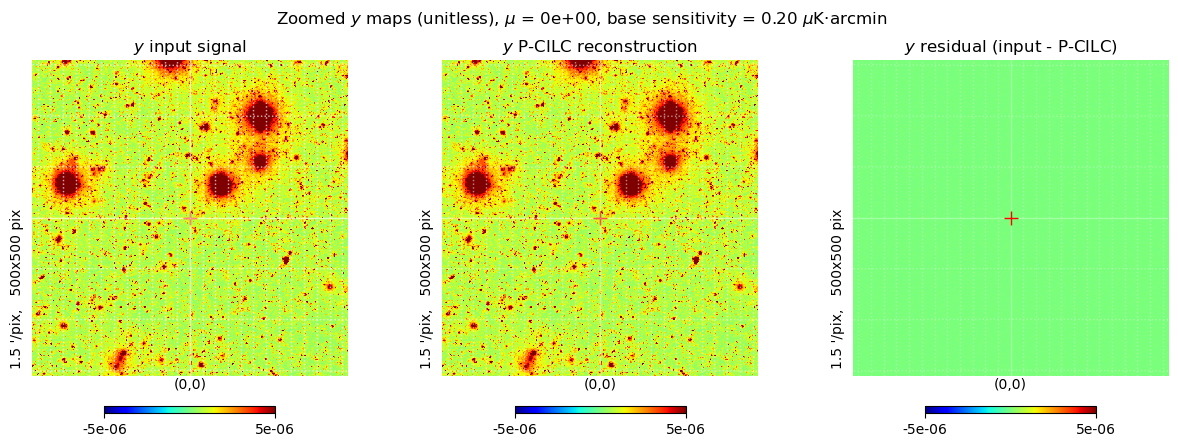

In [8]:
### A.1. PIXEL CILC ZOOMED MAPS ###

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(y_map, title=rf"$y$ input signal", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(y_hat_pixel_cilc, title=rf"$y$ P-CILC reconstruction", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(y_residual_pixel_cilc, title=rf"$y$ residual (input - P-CILC)", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle(rf"Zoomed $y$ maps (unitless), $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin")
plt.savefig(f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/y_maps/P-CILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# --- Build WCS matching healpy gnomonic projection ---
def build_gnomonic_wcs(rot, xsize, reso):
    w = WCS(naxis=2)

    cdelt = reso / 60.0  # deg/pixel

    # Reference pixel (center)
    w.wcs.crpix = [xsize / 2, xsize / 2]

    # Reference sky coordinate
    w.wcs.crval = [rot[0], rot[1]]

    # Projection type (Galactic TAN = gnomonic)
    w.wcs.ctype = ["GLON-TAN", "GLAT-TAN"]

    # For Equatorial coordinates, use:
    #w.wcs.ctype = ["RA---TAN", "DEC--TAN"]

    # Pixel scale (flip x-axis for correct orientation)
    w.wcs.cdelt = [-cdelt, cdelt]

    return w

In [ ]:
# ================= FULL WCS-BASED PLOTTING CELL =================

# --- Parameters ---
params_zoom_y = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True, 'min': -5*10**-6, 'max': 5*10**-6}

# --- Build WCS ---
wcs = build_gnomonic_wcs(
    rot=params_zoom_y['rot'],
    xsize=params_zoom_y['xsize'],
    reso=params_zoom_y['reso']
)

# --- Get projected maps from healpy ---
proj_map_1 = hp.gnomview(y_map, return_projected_map=True, no_plot=True, **params_zoom_y)
proj_map_2 = hp.gnomview(y_hat_pixel_cilc, return_projected_map=True, no_plot=True, **params_zoom_y)
proj_map_3 = hp.gnomview(y_residual_pixel_cilc, return_projected_map=True, no_plot=True, **params_zoom_y)

# --- Plot ---
fig = plt.figure(figsize=(15, 6))

# Panel 1
ax1 = plt.subplot(1, 3, 1, projection=wcs)
im1 = ax1.imshow(proj_map_1, origin='lower', cmap='jet',
                 vmin=params_zoom_y['min'], vmax=params_zoom_y['max'])
ax1.set_title(rf"$\mu y$ input signal")
ax1.coords.grid(True, color='white', alpha=0.3)
ax1.plot(params_zoom_y['xsize']/2, params_zoom_y['xsize']/2, marker='+', color='red', markersize=10, label='Center')

# Panel 2
ax2 = plt.subplot(1, 3, 2, projection=wcs)
im2 = ax2.imshow(proj_map_2, origin='lower', cmap='jet',
                 vmin=params_zoom_y['min'], vmax=params_zoom_y['max'])
ax2.set_title(rf"$\mu y$ P-CILC reconstruction")
ax2.coords.grid(True, color='white', alpha=0.3)
ax2.plot(params_zoom_y['xsize']/2, params_zoom_y['xsize']/2, marker='+', color='red', markersize=10, label='Center')

# Panel 3
ax3 = plt.subplot(1, 3, 3, projection=wcs)
im3 = ax3.imshow(proj_map_3, origin='lower', cmap='jet',
                 vmin=params_zoom_y['min'], vmax=params_zoom_y['max'])
ax3.set_title(rf"$\mu y$ residual (input - P-CILC)")
ax3.coords.grid(True, color='white', alpha=0.3)
ax3.plot(params_zoom_y['xsize']/2, params_zoom_y['xsize']/2, marker='+', color='red', markersize=10, label='Center')

# --- Axis labels (only left & bottom for cleanliness) ---
ax1.coords[0].set_axislabel("Galactic Longitude (deg)")
ax1.coords[1].set_axislabel("Galactic Latitude (deg)")
ax2.coords[0].set_axislabel("Galactic Longitude (deg)")
ax2.coords[1].set_axislabel("Galactic Latitude (deg)")
ax3.coords[0].set_axislabel("Galactic Longitude (deg)")
ax3.coords[1].set_axislabel("Galactic Latitude (deg)")

fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.1, orientation='horizontal')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.1, orientation='horizontal')
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.1, orientation='horizontal')

#cbar = fig.colorbar(im1, ax=[ax1, ax2, ax3], fraction=0.075, pad=0.15, orientation='horizontal')
#cbar.ax.tick_params(labelsize=10)

# --- Title & layout ---
plt.suptitle(rf"Zoomed $\mu y$ maps (unitless), $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin")
plt.tight_layout()

# --- Save ---
plt.savefig(f'/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/y_maps/P-CILC_zoomed_maps_WCS.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 3.2. P-CILC & H-CILC: $\mu y$-maps

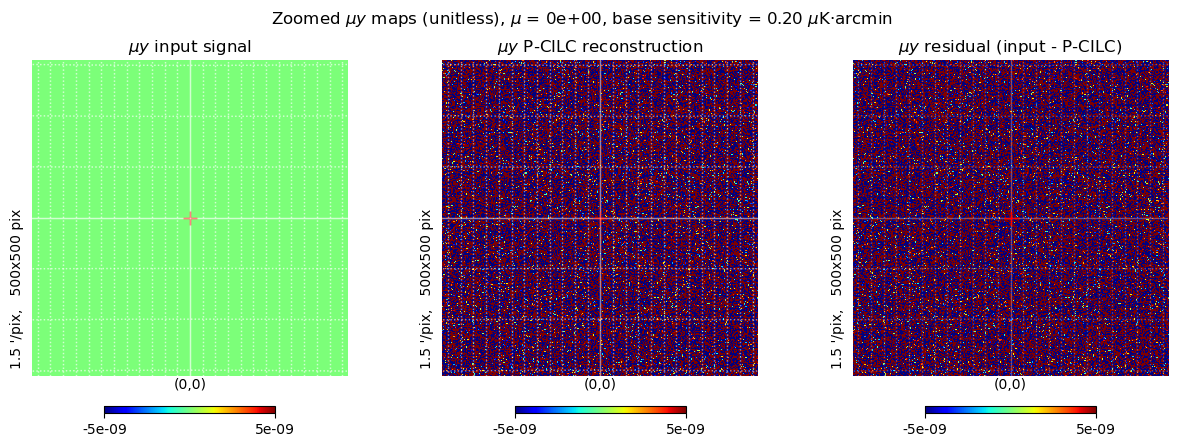

In [9]:
### A.1. PIXEL CILC ZOOMED MAPS ###

params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-9, 'max': 5*10**-9} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(muy_map, title=rf"$\mu y$ input signal", **params_zoom_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(muy_hat_pixel_cilc, title=rf"$\mu y$ P-CILC reconstruction", **params_zoom_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(muy_residual_pixel_cilc, title=rf"$\mu y$ residual (input - P-CILC)", **params_zoom_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle(rf"Zoomed $\mu y$ maps (unitless), $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin")
plt.savefig(f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/mu_y_maps/P-CILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# --- Build WCS matching healpy gnomonic projection ---
def build_gnomonic_wcs(rot, xsize, reso):
    w = WCS(naxis=2)

    cdelt = reso / 60.0  # deg/pixel

    # Reference pixel (center)
    w.wcs.crpix = [xsize / 2, xsize / 2]

    # Reference sky coordinate
    w.wcs.crval = [rot[0], rot[1]]

    # Projection type (Galactic TAN = gnomonic)
    w.wcs.ctype = ["GLON-TAN", "GLAT-TAN"]

    # For Equatorial coordinates, use:
    #w.wcs.ctype = ["RA---TAN", "DEC--TAN"]

    # Pixel scale (flip x-axis for correct orientation)
    w.wcs.cdelt = [-cdelt, cdelt]

    return w

In [ ]:
# ================= FULL WCS-BASED PLOTTING CELL =================

# --- Parameters ---
params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True, 'min': -5*10**-9, 'max': 5*10**-9}

# --- Build WCS ---
wcs = build_gnomonic_wcs(
    rot=params_zoom_muy['rot'],
    xsize=params_zoom_muy['xsize'],
    reso=params_zoom_muy['reso']
)

# --- Get projected maps from healpy ---
proj_map_1 = hp.gnomview(muy_map, return_projected_map=True, no_plot=True, **params_zoom_muy)
proj_map_2 = hp.gnomview(muy_hat_pixel_cilc, return_projected_map=True, no_plot=True, **params_zoom_muy)
proj_map_3 = hp.gnomview(muy_residual_pixel_cilc, return_projected_map=True, no_plot=True, **params_zoom_muy)

# --- Plot ---
fig = plt.figure(figsize=(15, 6))

# Panel 1
ax1 = plt.subplot(1, 3, 1, projection=wcs)
im1 = ax1.imshow(proj_map_1, origin='lower', cmap='jet',
                 vmin=params_zoom_muy['min'], vmax=params_zoom_muy['max'])
ax1.set_title(rf"$\mu y$ input signal")
ax1.coords.grid(True, color='white', alpha=0.3)
ax1.plot(params_zoom_muy['xsize']/2, params_zoom_muy['xsize']/2, marker='+', color='red', markersize=10, label='Center')

# Panel 2
ax2 = plt.subplot(1, 3, 2, projection=wcs)
im2 = ax2.imshow(proj_map_2, origin='lower', cmap='jet',
                 vmin=params_zoom_muy['min'], vmax=params_zoom_muy['max'])
ax2.set_title(rf"$\mu y$ P-CILC reconstruction")
ax2.coords.grid(True, color='white', alpha=0.3)
ax2.plot(params_zoom_muy['xsize']/2, params_zoom_muy['xsize']/2, marker='+', color='red', markersize=10, label='Center')

# Panel 3
ax3 = plt.subplot(1, 3, 3, projection=wcs)
im3 = ax3.imshow(proj_map_3, origin='lower', cmap='jet',
                 vmin=params_zoom_muy['min'], vmax=params_zoom_muy['max'])
ax3.set_title(rf"$\mu y$ residual (input - P-CILC)")
ax3.coords.grid(True, color='white', alpha=0.3)
ax3.plot(params_zoom_muy['xsize']/2, params_zoom_muy['xsize']/2, marker='+', color='red', markersize=10, label='Center')

# --- Axis labels (only left & bottom for cleanliness) ---
ax1.coords[0].set_axislabel("Galactic Longitude (deg)")
ax1.coords[1].set_axislabel("Galactic Latitude (deg)")
ax2.coords[0].set_axislabel("Galactic Longitude (deg)")
ax2.coords[1].set_axislabel("Galactic Latitude (deg)")
ax3.coords[0].set_axislabel("Galactic Longitude (deg)")
ax3.coords[1].set_axislabel("Galactic Latitude (deg)")

fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.1, orientation='horizontal')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.1, orientation='horizontal')
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.1, orientation='horizontal')

#cbar = fig.colorbar(im1, ax=[ax1, ax2, ax3], fraction=0.075, pad=0.15, orientation='horizontal')
#cbar.ax.tick_params(labelsize=10)

# --- Title & layout ---
plt.suptitle(rf"Zoomed $\mu y$ maps (unitless), $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin")
plt.tight_layout()

# --- Save ---
plt.savefig(f'/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/mu_y_maps/P-CILC_zoomed_maps_WCS.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 4. P-ILC Vs. P-CILC

### 4.1. $y$-maps

In [11]:
### PIXEL ILC VS CILC RESIDUALS ###

# Calculate the residual difference between P-ILC and P-CILC
y_residual_pcilc_pilc = y_hat_pixel_ilc - y_hat_pixel_cilc

print(f"Max Residual (P-ILC): {np.max(y_residual_pixel_ilc):.2e}")
print(f"Max Residual (P-CILC): {np.max(y_residual_pixel_cilc):.2e}")
print(f"Max Residual Difference (P-ILC - P-CILC): {np.max(y_residual_pcilc_pilc):.2e}")

Max Residual (P-ILC): 1.62e-07
Max Residual (P-CILC): 1.42e-07
Max Residual Difference (P-ILC - P-CILC): 1.66e-07


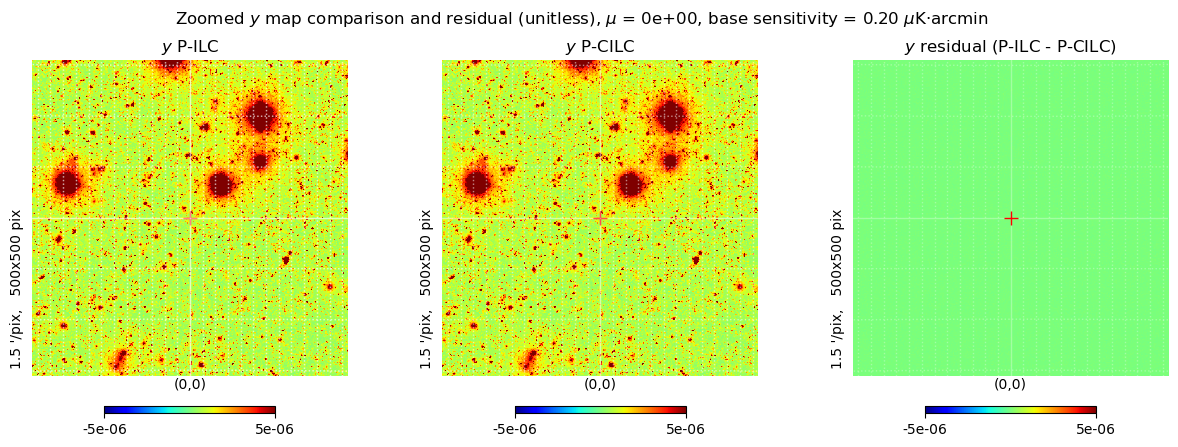

In [12]:
### PLOT THE RESIDUAL DIFFERENCE BETWEEN P-ILC AND P-CILC ###

params_zoom_y = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6}
params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-8, 'max': 5*10**-8}
#params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13}

# Plotting the residual difference
fig_residual_comparison = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(y_hat_pixel_ilc, title=rf"$y$ P-ILC", **params_zoom_y)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(y_hat_pixel_cilc, title=rf"$y$ P-CILC", **params_zoom_y)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(y_residual_pcilc_pilc, title=rf"$y$ residual (P-ILC - P-CILC)", **params_zoom_y)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')
plt.suptitle(rf"Zoomed $y$ map comparison and residual (unitless), $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin")
plt.savefig(f'/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/ILC_VS_CILC_{mu:.0e}/y_maps/Residual_Comparison_P-CILC_VS_P-ILC.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 4.2. $\mu y$-maps

In [13]:
### PIXEL ILC VS CILC RESIDUALS for muy-map ###

# Calculate the residual difference between P-ILC and P-CILC
muy_residual_pcilc_pilc = muy_hat_pixel_ilc - muy_hat_pixel_cilc

print(f"Max Residual (P-ILC): {np.max(muy_residual_pixel_ilc):.2e}")
print(f"Max Residual (P-CILC): {np.max(muy_residual_pixel_cilc):.2e}")
print(f"Max Residual Difference (P-ILC - P-CILC): {np.max(muy_residual_pcilc_pilc):.2e}")

Max Residual (P-ILC): 4.88e-06
Max Residual (P-CILC): 4.15e-07
Max Residual Difference (P-ILC - P-CILC): 4.04e-06


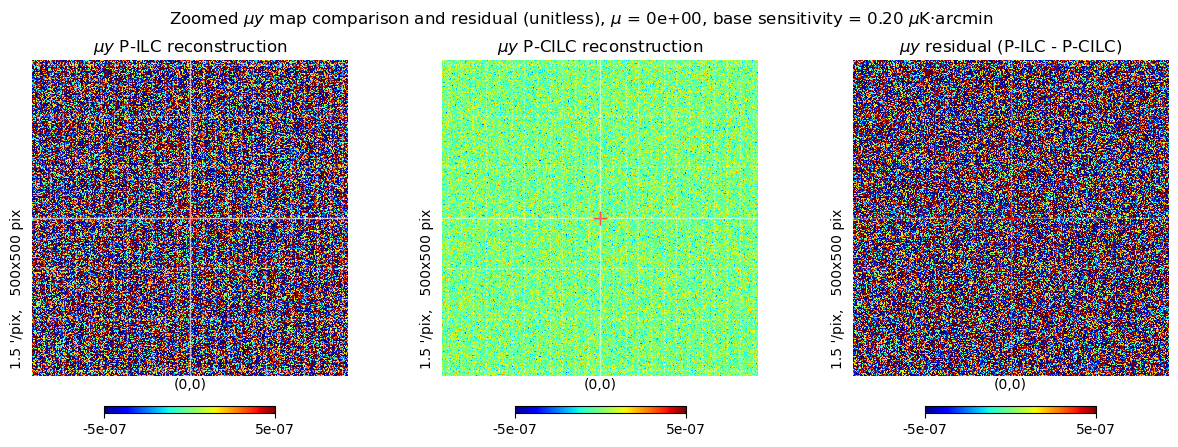

In [14]:
### PLOT THE RESIDUAL DIFFERENCE BETWEEN P-ILC AND P-CILC ###

#params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-9, 'max': 5*10**-9}
params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-7, 'max': 5*10**-7}

# Plotting the residual difference
fig_residual_comparison = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(muy_hat_pixel_ilc, title=rf"$\mu y$ P-ILC reconstruction", **params_zoom_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(muy_hat_pixel_cilc, title=rf"$\mu y$ P-CILC reconstruction", **params_zoom_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(muy_residual_pcilc_pilc, title=rf"$\mu y$ residual (P-ILC - P-CILC)", **params_zoom_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')
plt.suptitle(rf"Zoomed $\mu y$ map comparison and residual (unitless), $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin")
plt.savefig(f'/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/ILC_VS_CILC_{mu:.0e}/mu_y_maps/Residual_Comparison_P-CILC_VS_P-ILC.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 5. Staking

### 5.1. Calculating cluster galactic coordinates: (l,b)

### $10^3$

In [16]:
def get_brightest_cluster_coords(y_map, n_clusters=1000, min_dist_deg=1.0):
    """Finds the coordinates of the n brightest clusters."""
    # Create a copy to avoid modifying original
    temp_map = np.copy(y_map)
    nside = hp.npix2nside(len(temp_map))
    coords = []
    
    for i in range(n_clusters):
        # Find pixel with maximum value
        pix_max = np.argmax(temp_map)
        
        # Convert to Galactic coordinates
        theta, phi = hp.pix2ang(nside, pix_max)
        lon = np.degrees(phi)
        lat = 90 - np.degrees(theta)
        coords.append((lon, lat))
        
        # Zero out the surrounding area so we don't pick the same cluster
        # A 1-degree radius is usually enough for WebSky clusters
        vec = hp.pix2vec(nside, pix_max)
        disc_pix = hp.query_disc(nside, vec, radius=np.radians(min_dist_deg))
        temp_map[disc_pix] = 0
        
    return coords

In [18]:
### EXTRACTING THE COORDINATES OF THE 10^3 BRIGHTEST CLUSTERS ###
cluster_coords_10e3 = get_brightest_cluster_coords(y_map, n_clusters=1000, min_dist_deg=1.0)
print(f"Coordinates of the {len(cluster_coords_10e3)} brightest clusters.")
print("Only the first 10 are shown for brevity (lon, lat) in degrees):")
for i, (lon, lat) in enumerate(cluster_coords_10e3[:5]):  # Print only the first 10 for brevity
    print(f"{i+1}: (lon: {lon:.2f}, lat: {lat:.2f})")

Coordinates of the 1000 brightest clusters.
Only the first 10 are shown for brevity (lon, lat) in degrees):
1: (lon: 33.25, lat: -42.09)
2: (lon: 267.82, lat: -11.49)
3: (lon: 115.58, lat: -7.54)
4: (lon: 281.82, lat: -13.77)
5: (lon: 105.11, lat: 57.23)


Hi Mathieu,

Here you are a new update of what I've been working on since last Wednesday:

I have given diferent radii values and calculated the area inside the cirlce for each case for μ = 2e-05.

For 10^4 clusters the results improve significantly for  μ = 5e-05. However, the 10^5 case is giving me problem as the kernel crashes overnight, I believe it is a matter of my laptop's memory... I can give it some more chances yet, probably the code can be optimized.

In addition, I think it is quite easy right now for me to stack 10^4 for the other μ values as the structure is already generated. I just have to change the μ value, run the hole notebook and wait while I am afk.

I'm not sure if I understood correctly the null test, for μ = 0e+00 (labeled like this to facilitate myself the storage of data... I use something like CILC_{mu:.0e}_maps, so I must change the μ value at the beginning of the notebook and then just run it all). I have used a 4-layer map as I understood from the meeting, but of course that makes the signal to be there but I am not to reconstructing it. Should I use a 3 layer "mu*y-free" map?

I have updated the slides and you can check all these results if you wish and are not very busy (https://github.com/JoanRibotOliver/TFM.git).

Finally, there are some things left for me to try before the next meeting, but I must also prepare the Cosmology presentation due to next week, so I might not have too much time for the thesis during the weekend, Monday and Tuesday :(.
So the Bootstrap method and the analysis of the Cross- Vs. Autp- power spectrum might be a bit incomplete on Wednesday. Anyways, I will let you know if I work on them.


Best,

In [20]:
### SAVE THE COORDINATES OF THE 10^3 BRIGHTEST CLUSTERS IN A .TXT FILE AND A .NPY FILE FOR FUTURE USE ###

# 1. Define and create the general directory
base_coord_dir = "/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/"
if not os.path.exists(base_coord_dir):
    os.makedirs(base_coord_dir)

# 2. Function to save coordinates (Human readable and Machine readable)
def save_cluster_coords(coords, n_label=1000):
    """
    coords: the list of (lon, lat) tuples
    n_label: string like '10e3', '10e4', or '10e5'
    """
    # Save as .npy for fast loading in Python (Highly Recommended)
    npy_path = os.path.join(base_coord_dir, f"coords_{n_label}.npy")
    np.save(npy_path, np.array(coords))
    
    # Save as .txt for human reading (Full list)
    txt_path = os.path.join(base_coord_dir, f"coords_{n_label}.txt")
    with open(txt_path, 'w') as f:
        f.write(f"Brightest Clusters Coordinates - Count: {len(coords)}\n")
        f.write("lon, lat (degrees)\n")
        for lon, lat in coords:
            f.write(f"{lon:.6f}, {lat:.6f}\n")
            
    print(f"Saved {len(coords)} coordinates to:")
    print(f"  - {npy_path}")
    print(f"  - {txt_path}")

# --- Usage ---
# Assuming you have your calculated coords in a variable:
save_cluster_coords(cluster_coords_10e3, "10e3")
# save_cluster_coords(cluster_coords_10e4, "10e4")
# save_cluster_coords(cluster_coords_10e5, "10e5")

Saved 1000 coordinates to:
  - /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_10e3.npy
  - /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_10e3.txt


In [21]:
### READ THE COORDINATES OF THE 10^3 BRIGHTEST CLUSTERS FROM THE .NPY FILE ###

n_label = "10e3" # or "10e4", etc.
input_path = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_{n_label}.npy"

# Load and convert back to list of tuples
cluster_coords_10e3 = [tuple(x) for x in np.load(input_path)]

print(f"Read {len(cluster_coords_10e3)} coordinates from {input_path}")

Read 1000 coordinates from /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_10e3.npy


In [25]:
### READ THE COORDINATES OF THE 10^3 BRIGHTEST CLUSTERS FROM THE .TXT FILE ###

def read_coords_from_txt(n_label):
    input_path = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_{n_label}.txt"
    coords = []
    with open(input_path, 'r') as f:
        # Skip the 2 header lines
        lines = f.readlines()[2:]
        for line in lines:
            if line.strip(): # ignore empty lines
                lon_str, lat_str = line.split(",")
                coords.append((float(lon_str), float(lat_str)))
    print(f"Read {len(coords)} coordinates from {input_path}")
    return coords

# Usage:
cluster_coords_10e3 = read_coords_from_txt("10e3")


Read 1000 coordinates from /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_10e3.txt


### $10^4$

In [ ]:
def get_brightest_cluster_coords(y_map, n_clusters=10000, min_dist_deg=1.0):
    """Finds the coordinates of the n brightest clusters."""
    # Create a copy to avoid modifying original
    temp_map = np.copy(y_map)
    nside = hp.npix2nside(len(temp_map))
    coords = []
    
    for i in range(n_clusters):
        # Find pixel with maximum value
        pix_max = np.argmax(temp_map)
        
        # Convert to Galactic coordinates
        theta, phi = hp.pix2ang(nside, pix_max)
        lon = np.degrees(phi)
        lat = 90 - np.degrees(theta)
        coords.append((lon, lat))
        
        # Zero out the surrounding area so we don't pick the same cluster
        # A 1-degree radius is usually enough for WebSky clusters
        vec = hp.pix2vec(nside, pix_max)
        disc_pix = hp.query_disc(nside, vec, radius=np.radians(min_dist_deg))
        temp_map[disc_pix] = 0
        
    return coords

In [ ]:
### EXTRACTING THE COORDINATES OF THE 10^4 BRIGHTEST CLUSTERS ###
cluster_coords = get_brightest_cluster_coords(y_map, n_clusters=10000, min_dist_deg=1.0)
print(f"Coordinates of the {len(cluster_coords)} brightest clusters.")
print("Only the first 10 are shown for brevity (lon, lat) in degrees):")
for i, (lon, lat) in enumerate(cluster_coords[:10]):  # Print only the first 10 for brevity
    print(f"{i+1}: (lon: {lon:.2f}, lat: {lat:.2f})")

In [ ]:
### SAVE THE COORDINATES OF THE 10^4 BRIGHTEST CLUSTERS IN A .TXT FILE AND A .NPY FILE FOR FUTURE USE ###

# 1. Define and create the general directory
base_coord_dir = "/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/"
if not os.path.exists(base_coord_dir):
    os.makedirs(base_coord_dir)

# 2. Function to save coordinates (Human readable and Machine readable)
def save_cluster_coords(coords, n_label=10000):
    """
    coords: the list of (lon, lat) tuples
    n_label: string like '10e3', '10e4', or '10e5'
    """
    # Save as .npy for fast loading in Python (Highly Recommended)
    npy_path = os.path.join(base_coord_dir, f"coords_{n_label}.npy")
    np.save(npy_path, np.array(coords))
    
    # Save as .txt for human reading (Full list)
    txt_path = os.path.join(base_coord_dir, f"coords_{n_label}.txt")
    with open(txt_path, 'w') as f:
        f.write(f"Brightest Clusters Coordinates - Count: {len(coords)}\n")
        f.write("lon, lat (degrees)\n")
        for lon, lat in coords:
            f.write(f"{lon:.6f}, {lat:.6f}\n")
            
    print(f"Saved {len(coords)} coordinates to:")
    print(f"  - {npy_path}")
    print(f"  - {txt_path}")

# --- Usage ---
# Assuming you have your calculated coords in a variable:
save_cluster_coords(cluster_coords_10e4, "10e4")

In [ ]:
### READ THE COORDINATES OF THE 10^4 BRIGHTEST CLUSTERS FROM THE .NPY FILE ###

n_label = "10e4"
input_path = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_{n_label}.npy"

# Load and convert back to list of tuples
cluster_coords_10e4 = [tuple(x) for x in np.load(input_path)]

print(f"Read {len(cluster_coords_10e4)} coordinates from {input_path}")

Read 1000 coordinates from /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_10e3.npy


In [ ]:
### READ THE COORDINATES OF THE 10^4 BRIGHTEST CLUSTERS FROM THE .TXT FILE ###

def read_coords_from_txt(n_label):
    input_path = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_{n_label}.txt"
    coords = []
    with open(input_path, 'r') as f:
        # Skip the 2 header lines
        lines = f.readlines()[2:]
        for line in lines:
            if line.strip(): # ignore empty lines
                lon_str, lat_str = line.split(",")
                coords.append((float(lon_str), float(lat_str)))
    print(f"Read {len(coords)} coordinates from {input_path}")
    return coords

# Usage:
cluster_coords_10e4 = read_coords_from_txt("10e4")


Read 1000 coordinates from /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_10e3.txt


### $10^5$

In [ ]:
def get_brightest_cluster_coords(y_map, n_clusters=100000, min_dist_deg=1.0):
    """Finds the coordinates of the n brightest clusters."""
    # Create a copy to avoid modifying original
    temp_map = np.copy(y_map)
    nside = hp.npix2nside(len(temp_map))
    coords = []
    
    for i in range(n_clusters):
        # Find pixel with maximum value
        pix_max = np.argmax(temp_map)
        
        # Convert to Galactic coordinates
        theta, phi = hp.pix2ang(nside, pix_max)
        lon = np.degrees(phi)
        lat = 90 - np.degrees(theta)
        coords.append((lon, lat))
        
        # Zero out the surrounding area so we don't pick the same cluster
        # A 1-degree radius is usually enough for WebSky clusters
        vec = hp.pix2vec(nside, pix_max)
        disc_pix = hp.query_disc(nside, vec, radius=np.radians(min_dist_deg))
        temp_map[disc_pix] = 0
        
    return coords

In [ ]:
### EXTRACTING THE COORDINATES OF THE 10^5 BRIGHTEST CLUSTERS ###
cluster_coords = get_brightest_cluster_coords(y_map, n_clusters=100000, min_dist_deg=1.0)
print(f"Coordinates of the {len(cluster_coords)} brightest clusters.")
print("Only the first 10 are shown for brevity (lon, lat) in degrees):")
for i, (lon, lat) in enumerate(cluster_coords[:10]):  # Print only the first 10 for brevity
    print(f"{i+1}: (lon: {lon:.2f}, lat: {lat:.2f})")

In [ ]:
### SAVE THE COORDINATES OF THE 10^5 BRIGHTEST CLUSTERS IN A .TXT FILE AND A .NPY FILE FOR FUTURE USE ###

# 1. Define and create the general directory
base_coord_dir = "/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/"
if not os.path.exists(base_coord_dir):
    os.makedirs(base_coord_dir)

# 2. Function to save coordinates (Human readable and Machine readable)
def save_cluster_coords(coords, n_label=100000):
    """
    coords: the list of (lon, lat) tuples
    n_label: string like '10e3', '10e4', or '10e5'
    """
    # Save as .npy for fast loading in Python (Highly Recommended)
    npy_path = os.path.join(base_coord_dir, f"coords_{n_label}.npy")
    np.save(npy_path, np.array(coords))
    
    # Save as .txt for human reading (Full list)
    txt_path = os.path.join(base_coord_dir, f"coords_{n_label}.txt")
    with open(txt_path, 'w') as f:
        f.write(f"Brightest Clusters Coordinates - Count: {len(coords)}\n")
        f.write("lon, lat (degrees)\n")
        for lon, lat in coords:
            f.write(f"{lon:.6f}, {lat:.6f}\n")
            
    print(f"Saved {len(coords)} coordinates to:")
    print(f"  - {npy_path}")
    print(f"  - {txt_path}")

# --- Usage ---
# Assuming you have your calculated coords in a variable:
save_cluster_coords(cluster_coords_10e5, "10e5")

In [ ]:
### READ THE COORDINATES OF THE 10^5 BRIGHTEST CLUSTERS FROM THE .NPY FILE ###

n_label = "10e5"
input_path = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_{n_label}.npy"

# Load and convert back to list of tuples
cluster_coords_10e5 = [tuple(x) for x in np.load(input_path)]

print(f"Read {len(cluster_coords_10e5)} coordinates from {input_path}")

Read 1000 coordinates from /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_10e3.npy


In [ ]:
### READ THE COORDINATES OF THE 10^5 BRIGHTEST CLUSTERS FROM THE .TXT FILE ###

def read_coords_from_txt(n_label):
    input_path = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_{n_label}.txt"
    coords = []
    with open(input_path, 'r') as f:
        # Skip the 2 header lines
        lines = f.readlines()[2:]
        for line in lines:
            if line.strip(): # ignore empty lines
                lon_str, lat_str = line.split(",")
                coords.append((float(lon_str), float(lat_str)))
    print(f"Read {len(coords)} coordinates from {input_path}")
    return coords

# Usage:
cluster_coords_10e5 = read_coords_from_txt("10e5")


Read 1000 coordinates from /Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/Brightest_clusters_coordinates/coords_10e3.txt


### 5.2. Stacking clusters from $y$ and $\mu y$ maps

In [26]:
def stack_clusters(hp_map, coords, reso_arcmin=1.5, xsize=100):
    """Stacks small patches around specified coordinates."""
    stacked_patch = np.zeros((xsize, xsize))
    
    for lon, lat in coords:
        # Project a small area into a flat 2D patch
        patch = hp.gnomview(hp_map, rot=[lon, lat], reso=reso_arcmin, 
                            xsize=xsize, return_projected_map=True, no_plot=True)
        stacked_patch += patch
        
    return stacked_patch / len(coords)

### $10^3$

In [57]:
### STACKING THE INPUT SIGNALS AROUND THE 10^3 BRIGHTEST CLUSTERS - test on the stacking method ###

# Use the truth maps first to verify the method)
stack_y_real_10e3 = stack_clusters(y_map, cluster_coords)
stack_muy_real_10e3 = stack_clusters(muy_map, cluster_coords)

In [58]:
### SAVE THE STACKED INPUT SIGNALS IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps_10e3 = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+03/"
path_y_real_10e3 = f"{path_stacked_maps_10e3}Input_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map_{len(cluster_coords)}.fits"
path_muy_real_10e3 = f"{path_stacked_maps_10e3}Input_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_real_10e3, stack_y_real_10e3.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_real_10e3, stack_muy_real_10e3.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_real_10e3.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_real_10e3.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y, mu_y): {stack_y_real_10e3.shape}, {stack_muy_real_10e3.shape}") # This will now be (100, 100)
print(f"Data dtypes (y, mu_y): {stack_y_real_10e3.dtype}, {stack_muy_real_10e3.dtype}")
print(f"Memory usage (y, mu_y): {stack_y_real_10e3.nbytes / 1e6:.2f} MB, {stack_muy_real_10e3.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

Stacked y_map saved successfully as 'Input_6freq_0.2muK_y_map_1000.fits'.
Stacked mu_y_map saved successfully as 'Input_6freq_0.2muK_mu_y_map_1000.fits'.
--------------------------------------------------
--- y and mu_y (hat) Stacked Input Information ---
--------------------------------------------------
mu = 0e+00
Number of clusters stacked: 1000
Stacked Patch shapes (y, mu_y): (100, 100), (100, 100)
Data dtypes (y, mu_y): float64, float64
Memory usage (y, mu_y): 0.08 MB, 0.08 MB
Frequencies used: [30, 40, 90, 150, 220, 270] GHz
Date and Time: 2026-05-14 12:41:55
--------------------------------------------------


In [59]:
### STACKING THE P-ILC SIGNALS AROUND THE 10^3 BRIGHTEST CLUSTERS ###

# Extract stacked signals from the P-ILC reconstructions
stack_y_ilc_10e3 = stack_clusters(y_hat_pixel_ilc, cluster_coords)
stack_muy_ilc_10e3 = stack_clusters(muy_hat_pixel_ilc, cluster_coords)

In [60]:
### SAVE THE 10^3 STACKED P-ILC IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps_10e3 = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+03/"
path_y_ilc_10e3 = f"{path_stacked_maps_10e3}P_ILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits"
path_muy_ilc_10e3 = f"{path_stacked_maps_10e3}P_ILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_ilc_10e3, stack_y_ilc_10e3.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_ilc_10e3, stack_muy_ilc_10e3.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_ilc_10e3.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_ilc_10e3.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y, mu_y): {stack_y_ilc_10e3.shape}, {stack_muy_ilc_10e3.shape}") # This will now be (100, 100)
print(f"Data dtypes (y, mu_y): {stack_y_ilc_10e3.dtype}, {stack_muy_ilc_10e3.dtype}")
print(f"Memory usage (y, mu_y): {stack_y_ilc_10e3.nbytes / 1e6:.2f} MB, {stack_muy_ilc_10e3.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

Stacked y_map saved successfully as 'P_ILC_6freq_0.2muK_y_map_1000.fits'.
Stacked mu_y_map saved successfully as 'P_ILC_6freq_0.2muK_mu_y_map_1000.fits'.
--------------------------------------------------
--- y and mu_y (hat) Stacked Input Information ---
--------------------------------------------------
mu = 0e+00
Number of clusters stacked: 1000
Stacked Patch shapes (y, mu_y): (100, 100), (100, 100)
Data dtypes (y, mu_y): float64, float64
Memory usage (y, mu_y): 0.08 MB, 0.08 MB
Frequencies used: [30, 40, 90, 150, 220, 270] GHz
Date and Time: 2026-05-14 12:46:45
--------------------------------------------------


In [61]:
### STACKING THE P-CILC SIGNALS AROUND THE 10^3 BRIGHTEST CLUSTERS ###

# Extract stacked signals from the P-CILC reconstructions
stack_y_cilc_10e3 = stack_clusters(y_hat_pixel_cilc, cluster_coords)
stack_muy_cilc_10e3 = stack_clusters(muy_hat_pixel_cilc, cluster_coords)

In [62]:
### SAVE THE 10^3 STACKED P-CILC IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps_10e3 = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+03/"
path_y_cilc_10e3 = f"{path_stacked_maps_10e3}P_CILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits"
path_muy_cilc_10e3 = f"{path_stacked_maps_10e3}P_CILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_cilc_10e3, stack_y_cilc_10e3.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_cilc_10e3, stack_muy_cilc_10e3.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_cilc_10e3.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_cilc_10e3.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y and mu_y): {stack_y_cilc_10e3.shape}, {stack_muy_cilc_10e3.shape}") # This will now be (100, 100)
print(f"Data dtypes (y and mu_y): {stack_y_cilc_10e3.dtype}, {stack_muy_cilc_10e3.dtype}")
print(f"Memory usage (y and mu_y): {stack_y_cilc_10e3.nbytes / 1e6:.2f} MB, {stack_muy_cilc_10e3.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

Stacked y_map saved successfully as 'P_CILC_6freq_0.2muK_y_map_1000.fits'.
Stacked mu_y_map saved successfully as 'P_CILC_6freq_0.2muK_mu_y_map_1000.fits'.
--------------------------------------------------
--- y and mu_y (hat) Stacked Input Information ---
--------------------------------------------------
mu = 0e+00
Number of clusters stacked: 1000
Stacked Patch shapes (y and mu_y): (100, 100), (100, 100)
Data dtypes (y and mu_y): float64, float64
Memory usage (y and mu_y): 0.08 MB, 0.08 MB
Frequencies used: [30, 40, 90, 150, 220, 270] GHz
Date and Time: 2026-05-14 12:50:50
--------------------------------------------------


### $10^4$

In [ ]:
### STACKING THE INPUT SIGNALS AROUND THE 10^4 BRIGHTEST CLUSTERS - test on the stacking method ###

# Use the truth maps first to verify the method)
stack_y_real_10e4 = stack_clusters(y_map, cluster_coords)
stack_muy_real_10e4 = stack_clusters(muy_map, cluster_coords)

In [ ]:
### SAVE THE 10^4 STACKED INPUT SIGNALS IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+04/"
path_y_real_10e4 = f"{path_stacked_maps}Input_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map_{len(cluster_coords)}.fits"
path_muy_real_10e4 = f"{path_stacked_maps}Input_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_real_10e4, stack_y_real_10e4.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_real_10e4, stack_muy_real_10e4.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_real_10e4.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_real_10e4.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y and mu_y): {stack_y_real_10e4.shape}, {stack_muy_real_10e4.shape}") # This will now be (100, 100)
print(f"Data dtypes (y and mu_y): {stack_y_real_10e4.dtype}, {stack_muy_real_10e4.dtype}")
print(f"Memory usage (y and mu_y): {stack_y_real_10e4.nbytes / 1e6:.2f} MB, {stack_muy_real_10e4.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

In [ ]:
### STACKING THE P-ILC SIGNALS AROUND THE 10^4 BRIGHTEST CLUSTERS ###

# Extract stacked signals from the P-ILC reconstructions
stack_y_ilc_10e4 = stack_clusters(y_hat_pixel_ilc, cluster_coords)
stack_muy_ilc_10e4 = stack_clusters(muy_hat_pixel_ilc, cluster_coords)

In [ ]:
### SAVE THE 10^4 STACKED P-ILC IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+04/"
path_y_ilc_10e4 = f"{path_stacked_maps}P_ILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits"
path_muy_ilc_10e4 = f"{path_stacked_maps}P_ILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_ilc_10e4, stack_y_ilc_10e4.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_ilc_10e4, stack_muy_ilc_10e4.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_ilc_10e4.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_ilc_10e4.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y and mu_y): {stack_y_ilc_10e4.shape}, {stack_muy_ilc_10e4.shape}") # This will now be (100, 100)
print(f"Data dtypes (y and mu_y): {stack_y_ilc_10e4.dtype}, {stack_muy_ilc_10e4.dtype}")
print(f"Memory usage (y and mu_y): {stack_y_ilc_10e4.nbytes / 1e6:.2f} MB, {stack_muy_ilc_10e4.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

In [ ]:
### STACKING THE P-CILC SIGNALS AROUND THE 10^4 BRIGHTEST CLUSTERS ###

# Extract stacked signals from the P-CILC reconstructions
stack_y_cilc_10e4 = stack_clusters(y_hat_pixel_cilc, cluster_coords)
stack_muy_cilc_10e4 = stack_clusters(muy_hat_pixel_cilc, cluster_coords)

In [ ]:
### SAVE THE 10^4 STACKED P-CILC IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/"
path_y_cilc_10e4 = f"{path_stacked_maps}P_CILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits"
path_muy_cilc_10e4 = f"{path_stacked_maps}P_CILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_cilc_10e4, stack_y_cilc_10e4.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_cilc_10e4, stack_muy_cilc_10e4.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_cilc_10e4.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_cilc_10e4.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y and mu_y): {stack_y_cilc_10e4.shape}, {stack_muy_cilc_10e4.shape}") # This will now be (100, 100)
print(f"Data dtypes (y and mu_y): {stack_y_cilc_10e4.dtype}, {stack_muy_cilc_10e4.dtype}")
print(f"Memory usage (y and mu_y): {stack_y_cilc_10e4.nbytes / 1e6:.2f} MB, {stack_muy_cilc_10e4.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

### $10^5$

In [ ]:
### STACKING THE INPUT SIGNALS AROUND THE 10^5 BRIGHTEST CLUSTERS - test on the stacking method ###

# Use the truth maps first to verify the method)
stack_y_real_10e5 = stack_clusters(y_map, cluster_coords)
stack_muy_real_10e5 = stack_clusters(muy_map, cluster_coords)

In [ ]:
### SAVE THE 10^5 STACKED INPUT SIGNALS IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+05/"
path_y_real_10e5 = f"{path_stacked_maps}Input_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_y_map_{len(cluster_coords)}.fits"
path_muy_real_10e5 = f"{path_stacked_maps}Input_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_real_10e5, stack_y_real_10e5.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_real_10e5, stack_muy_real_10e5.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_real_10e5.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_real_10e5.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y and mu_y): {stack_y_real_10e5.shape}, {stack_muy_real_10e5.shape}") # This will now be (100, 100)
print(f"Data dtypes (y and mu_y): {stack_y_real_10e5.dtype}, {stack_muy_real_10e5.dtype}")
print(f"Memory usage (y and mu_y): {stack_y_real_10e5.nbytes / 1e6:.2f} MB, {stack_muy_real_10e5.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

In [ ]:
### STACKING THE P-ILC SIGNALS AROUND THE 10^5 BRIGHTEST CLUSTERS ###

# Extract stacked signals from the P-ILC reconstructions
stack_y_ilc_10e5 = stack_clusters(y_hat_pixel_ilc, cluster_coords)
stack_muy_ilc_10e5 = stack_clusters(muy_hat_pixel_ilc, cluster_coords)

In [ ]:
### SAVE THE 10^5 STACKED P-ILC IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+05/"
path_y_ilc_10e5 = f"{path_stacked_maps}P_ILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits"
path_muy_ilc_10e5 = f"{path_stacked_maps}P_ILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_ilc_10e5, stack_y_ilc_10e5.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_ilc_10e5, stack_muy_ilc_10e5.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_ilc_10e5.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_ilc_10e5.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y and mu_y): {stack_y_ilc_10e5.shape}, {stack_muy_ilc_10e5.shape}") # This will now be (100, 100)
print(f"Data dtypes (y and mu_y): {stack_y_ilc_10e5.dtype}, {stack_muy_ilc_10e5.dtype}")
print(f"Memory usage (y and mu_y): {stack_y_ilc_10e5.nbytes / 1e6:.2f} MB, {stack_muy_ilc_10e5.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

In [ ]:
### STACKING THE P-CILC SIGNALS AROUND THE 10^5 BRIGHTEST CLUSTERS ###

# Extract stacked signals from the P-CILC reconstructions
stack_y_cilc_10e5 = stack_clusters(y_hat_pixel_cilc, cluster_coords)
stack_muy_cilc_10e5 = stack_clusters(muy_hat_pixel_cilc, cluster_coords)

In [ ]:
### SAVE THE 10^5 STACKED P-CILC IN THE LOCAL DISK ###

# Define file paths
path_stacked_maps = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+05/"
path_y_cilc_10e5 = f"{path_stacked_maps}P_CILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits"
path_muy_cilc_10e5 = f"{path_stacked_maps}P_CILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits"

# Save y_real patch using Astropy
fits.writeto(path_y_cilc_10e5, stack_y_cilc_10e5.astype(np.float32), overwrite=True)

# Save muy_real patch using Astropy
fits.writeto(path_muy_cilc_10e5, stack_muy_cilc_10e5.astype(np.float32), overwrite=True)

print(f"Stacked y_map saved successfully as '{path_y_cilc_10e5.split('/')[-1]}'.")
print(f"Stacked mu_y_map saved successfully as '{path_muy_cilc_10e5.split('/')[-1]}'.")

# --- Information prints ---
print("--------------------------------------------------")
print("--- y and mu_y (hat) Stacked Input Information ---")
print("--------------------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Number of clusters stacked: {len(cluster_coords)}")
print(f"Stacked Patch shapes (y and mu_y): {stack_y_cilc_10e5.shape}, {stack_muy_cilc_10e5.shape}") # This will now be (100, 100)
print(f"Data dtypes (y and mu_y): {stack_y_cilc_10e5.dtype}, {stack_muy_cilc_10e5.dtype}")
print(f"Memory usage (y and mu_y): {stack_y_cilc_10e5.nbytes / 1e6:.2f} MB, {stack_muy_cilc_10e5.nbytes / 1e6:.2f} MB")
print(f"Frequencies used: {zegeye_frequencies} GHz")
print("Date and Time:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("--------------------------------------------------")

### READ THE SAVED STACKED MAPS

In [33]:
### READ THE PREVIOUSLY COMPUTED STACKED 10^3 MAPS ###

# 1. Define the paths to your saved files
# Use the same naming convention used during the saving process
path_stacked_maps_10e3 = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+03/"

# 2. Read the 2D data arrays
stack_y_real_10e3 = fits.getdata(f"{path_stacked_maps_10e3}Input_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_real_10e3 = fits.getdata(f"{path_stacked_maps_10e3}Input_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

stack_y_ilc_10e3 = fits.getdata(f"{path_stacked_maps_10e3}P_ILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_ilc_10e3 = fits.getdata(f"{path_stacked_maps_10e3}P_ILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

stack_y_cilc_10e3 = fits.getdata(f"{path_stacked_maps_10e3}P_CILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_cilc_10e3 = fits.getdata(f"{path_stacked_maps_10e3}P_CILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

print(f"Stacked 10^3 maps read successfully at {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}.")

Stacked 10^3 maps read successfully at 2026-05-15 11:12:33.


In [ ]:
### READ THE PREVIOUSLY COMPUTED STACKED 10^4 MAPS ###

# 1. Define the paths to your saved files
# Use the same naming convention used during the saving process
path_stacked_maps_10e4 = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+04/"

# 2. Read the 2D data arrays
stack_y_10e4 = fits.getdata(f"{path_stacked_maps_10e4}Input_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_10e4 = fits.getdata(f"{path_stacked_maps_10e4}Input_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

stack_y_ilc_10e4 = fits.getdata(f"{path_stacked_maps_10e4}P_ILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_ilc_10e4 = fits.getdata(f"{path_stacked_maps_10e4}P_ILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

stack_y_cilc_10e4 = fits.getdata(f"{path_stacked_maps_10e4}P_CILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_cilc_10e4 = fits.getdata(f"{path_stacked_maps_10e4}P_CILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

print(f"Stacked 10^4 maps read successfully at {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}.")

In [ ]:
### READ THE PREVIOUSLY COMPUTED STACKED 10^5 MAPS ###

# 1. Define the paths to your saved files
# Use the same naming convention used during the saving process
path_stacked_maps_10e5 = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Stacked_maps/1e+05/"

# 2. Read the 2D data arrays
stack_y_10e5 = fits.getdata(f"{path_stacked_maps_10e5}Input_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_10e5 = fits.getdata(f"{path_stacked_maps_10e5}Input_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

stack_y_ilc_10e5 = fits.getdata(f"{path_stacked_maps_10e5}P_ILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_ilc_10e5 = fits.getdata(f"{path_stacked_maps_10e5}P_ILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

stack_y_cilc_10e5 = fits.getdata(f"{path_stacked_maps_10e5}P_CILC_6freq_0.2muK_y_map_{len(cluster_coords)}.fits")
stack_muy_cilc_10e5 = fits.getdata(f"{path_stacked_maps_10e5}P_CILC_6freq_0.2muK_mu_y_map_{len(cluster_coords)}.fits")

print(f"Stacked 10^5 maps read successfully at {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}.")

### 5.3. Plotting the stacked clusters

5.3.1. SINGLE STACKED MAP

In [ ]:
def plot_stacked_patches_one(stacked_map, n_clusters, filename, method_name):
    """
    Plots the average (stacked) patches for the only signal with a circle.
    """
    fig, ax = plt.subplots(figsize=(6, 5)) # Definim 'ax' per poder afegir el patch
    
    # Calculem l'extensió per centrar el mapa
    half_x = stacked_map.shape[0] // 2
    half_y = stacked_map.shape[1] // 2
    extent = [-half_x, half_x, -half_y, half_y]
    
    im = ax.imshow(stacked_map, origin='lower', cmap='jet', extent=extent)
    plt.colorbar(im, label='Average Signal (unitless)')
    
    # --- DIBUIX DEL CERCLE ---
    # Paràmetres: (centre_x, centre_y), radi, color...
    radi_cercle = 5  # Pots ajustar aquest valor segons l'escala dels teus píxels
    cercle = patches.Circle((0, 0), radi_cercle, color='black', fill=False, linewidth=1.5, linestyle='-')
    ax.add_patch(cercle)
    
    # Mantenim el punt central si vols marcar el centre exacte
    #ax.plot(0, 0, marker='+', color='white', markersize=10, label='Center')
    
    # Configuració de títols i etiquetes
    ax.set_title(f'{method_name} stacked patch of {n_clusters} brightest clusters')
    ax.set_xlabel('Pixels')
    ax.set_ylabel('Pixels')
    
    # Guardar i mostrar
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/Stacking/{filename}_{n_clusters}_clusters.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

5.3.2. COMPARISON OF 2 STACKED MAPS

In [64]:
def plot_two_stacked_patches(stack_y, stack_muy, n_clusters, mu, base_sensitivity_uk_arcmin, filename, method_name):
    """
    Plots the average (stacked) patches for the y and mu*y signals with circles.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    vmin_y, vmax_y = -10**-5, 10**-5
    vmin_muy, vmax_muy = -5*10**-9, 5*10**-9

    # Calculate extents to center the pixels around (0,0)
    # This assumes your stacks are square postage stamps
    extent_y = [-stack_y.shape[1]//2, stack_y.shape[1]//2, -stack_y.shape[0]//2, stack_y.shape[0]//2]
    extent_muy = [-stack_muy.shape[1]//2, stack_muy.shape[1]//2, -stack_muy.shape[0]//2, stack_muy.shape[0]//2]

    radi_cercle = 10

    # 1. Plot Stacked y-signal
    im1 = ax1.imshow(stack_y, origin='lower', cmap='jet', extent=extent_y)
    ax1.set_title(f"Stacked $y$ signal")
    fig.colorbar(im1, ax=ax1, label='Dimensionless y')
    ax1.set_xlabel("Pixels")
    ax1.set_ylabel("Pixels")
    
    # Create and add the FIRST circle
    cercle1 = patches.Circle((0, 0), radi_cercle, color='black', fill=False, linewidth=1.5, linestyle='-')
    ax1.add_patch(cercle1)

    # 2. Plot Stacked mu*y-signal
    im2 = ax2.imshow(stack_muy, origin='lower', cmap='jet', extent=extent_muy, vmin=vmin_muy, vmax=vmax_muy)
    ax2.set_title(rf"Stacked $\mu y$ Signal")
    cbar2 = fig.colorbar(im2, ax=ax2, label=rf'Dimensionless $\mu y$')
    cbar2.formatter.set_powerlimits((0, 0)) 
    ax2.set_xlabel("Pixels")
    ax2.set_ylabel("Pixels")
    
    # Create and add a SECOND circle for the second axis
    cercle2 = patches.Circle((0, 0), radi_cercle, color='black', fill=False, linewidth=1.5, linestyle='-')
    ax2.add_patch(cercle2)

    plt.suptitle(rf'{method_name} stacked patch of {n_clusters} brightest clusters, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r = {radi_cercle}$p ')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save the figure
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/Stacking/{n_clusters:.0e}/{filename}.pdf"
    #'/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_2e-04/Stacking/1e+4'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

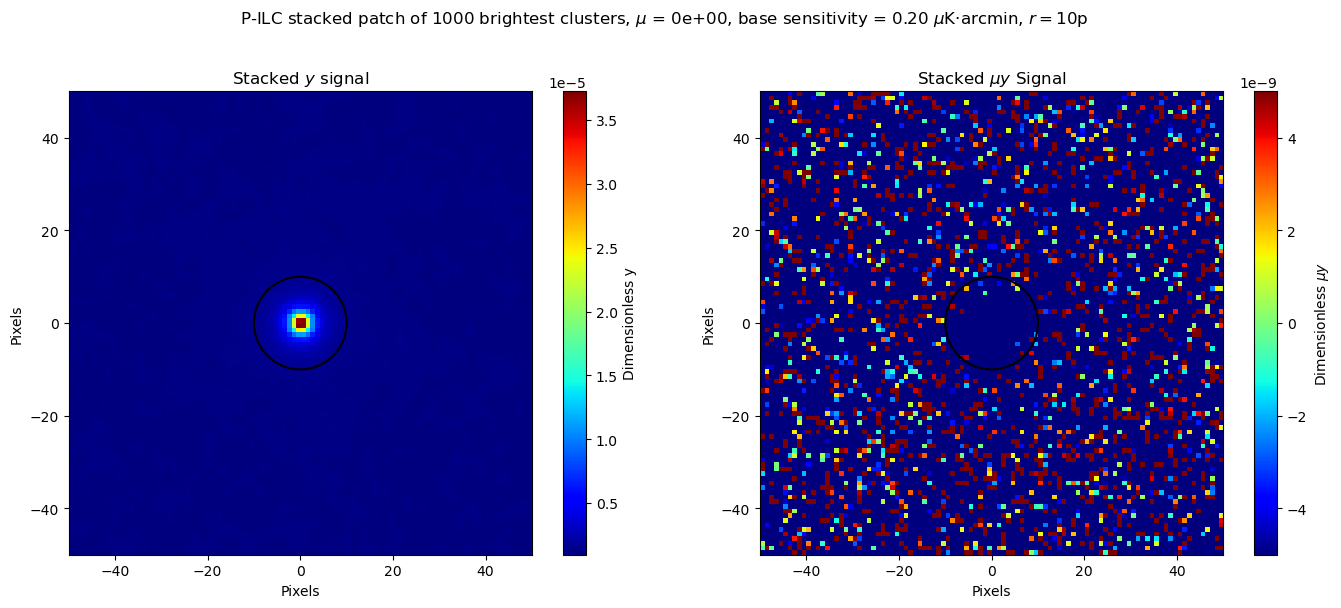

In [65]:
### PLOTING THE 10^3 STACKED PATCHES for P-ILC ###

plot_two_stacked_patches(stack_y_ilc_10e3, stack_muy_ilc_10e3, n_clusters=1000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_ILC", method_name="P-ILC")

In [ ]:
### PLOTING THE 10^4 STACKED PATCHES for P-ILC ###

plot_two_stacked_patches(stack_y_ilc_10e4, stack_muy_ilc_10e4, n_clusters=10000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_ILC", method_name="P-ILC")

In [ ]:
### PLOTING THE 10^5 STACKED PATCHES for P-ILC ###

plot_two_stacked_patches(stack_y_ilc_10e5, stack_muy_ilc_10e5, n_clusters=100000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_ILC", method_name="P-ILC")

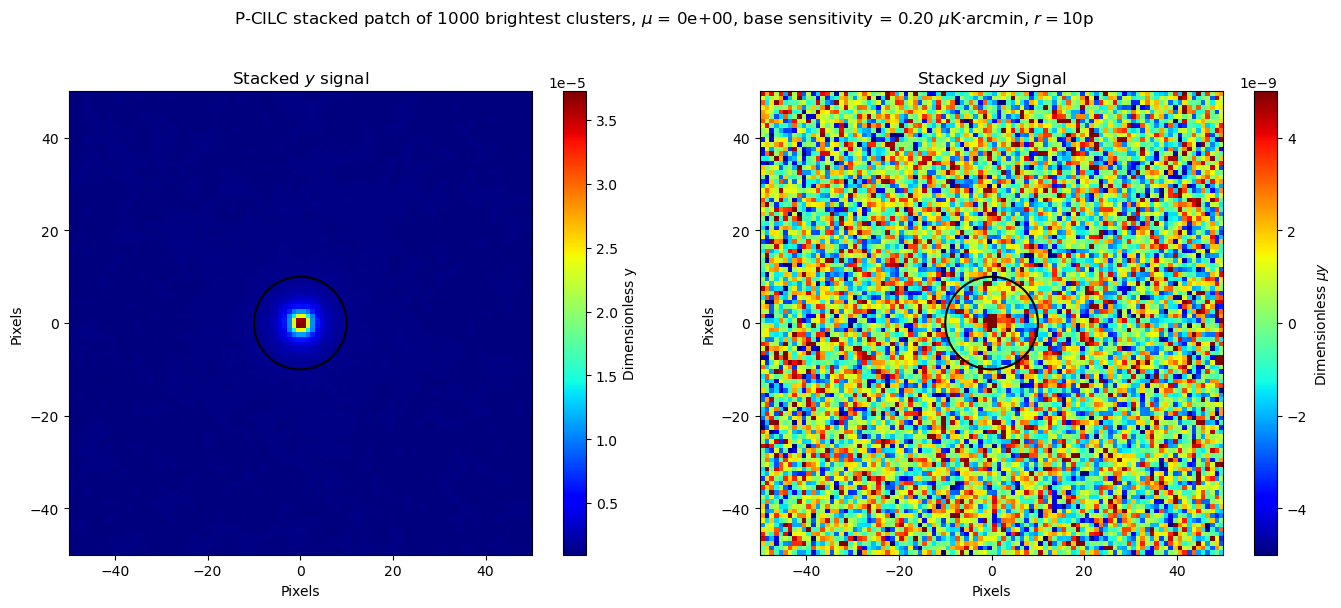

In [66]:
### PLOTING THE 10^3 STACKED PATCHES for P-CILC ###

plot_two_stacked_patches(stack_y_cilc_10e3, stack_muy_cilc_10e3, n_clusters=1000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_CILC", method_name="P-CILC")

In [ ]:
### PLOTING THE 10^4 STACKED PATCHES for P-CILC ###

plot_two_stacked_patches(stack_y_cilc_10e4, stack_muy_cilc_10e4, n_clusters=10000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_CILC", method_name="P-CILC")

In [ ]:
### PLOTING THE 10^5 STACKED PATCHES for P-CILC ###

plot_two_stacked_patches(stack_y_cilc_10e5, stack_muy_cilc_10e5, n_clusters=100000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_CILC", method_name="P-CILC")

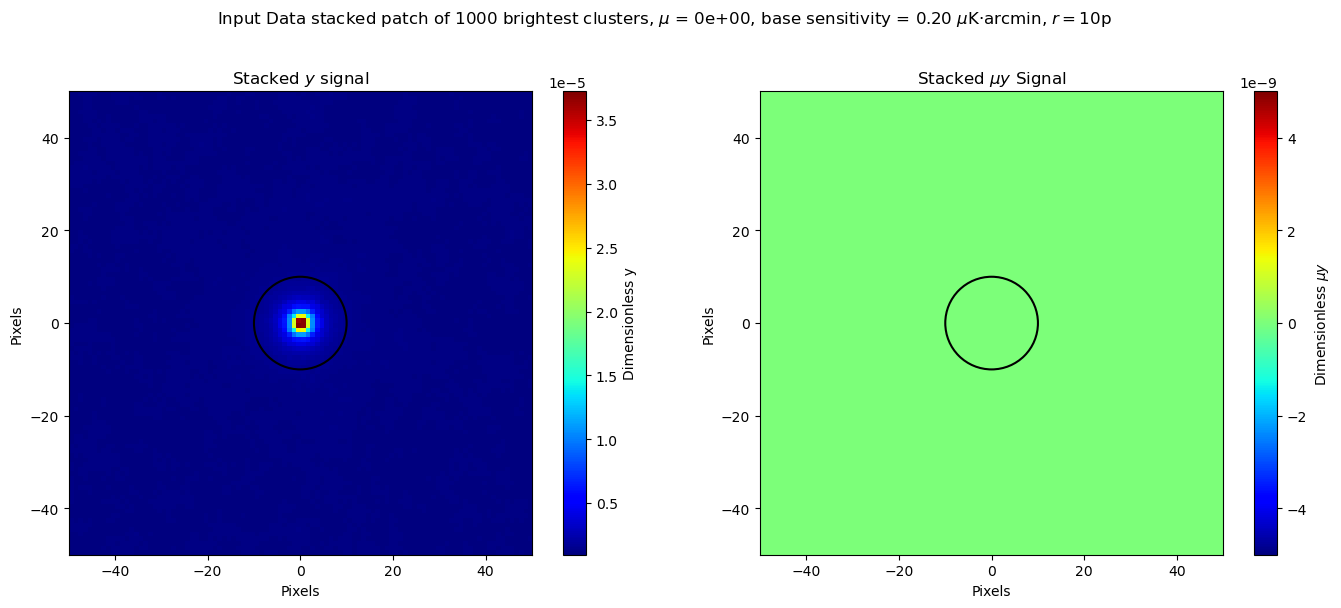

In [67]:
### PLOTING THE 10^3 STACKED PATCHES OF THE INPUT DATA ###

plot_two_stacked_patches(stack_y_real_10e3, stack_muy_real_10e3, n_clusters=1000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_Real_Data", method_name="Input Data")

In [ ]:
### PLOTING THE 10^4 STACKED PATCHES OF THE INPUT DATA ###

plot_two_stacked_patches(stack_y_real_10e4, stack_muy_real_10e4, n_clusters=10000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_Real_Data", method_name="Input Data")

In [ ]:
### PLOTING THE 10^5 STACKED PATCHES OF THE INPUT DATA ###

plot_two_stacked_patches(stack_y_real_10e5, stack_muy_real_10e5, n_clusters=100000, mu=mu, base_sensitivity_uk_arcmin=base_sensitivity_uk_arcmin, filename="Stacked_Patches_Real_Data", method_name="Input Data")

5.3.3. COMPARISON OF 3 STACKED MAPS

In [68]:
def plot_comparison_stacked_patches_y(stack_y_ilc, stack_y_cilc, stack_y_real, n_clusters, mu, base_sensitivity, map, filename):
    """
    Plots three comparison stacked patches (Pixel ILC, Pixel CILC, and Input Data) 
    in a single row for side-by-side comparison.
    """
    maps = [stack_y_ilc, stack_y_cilc, stack_y_real]
    titles = [r"P-ILC stacked $y$ map", r"P-CILC stacked $y$ map", r"Input data stacked $y$ map"]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Define colorbar limits based on your provided params
    # Using your intermediate mu-y scale as an example
    v_min, v_max = -5e-6, 5e-6

    for i, ax in enumerate(axes):
        # Calculate extents to center the pixels around (0,0)
        extent = [-maps[i].shape[1]//2, maps[i].shape[1]//2, -maps[i].shape[0]//2, maps[i].shape[0]//2]
        
        im = ax.imshow(maps[i], origin='lower', cmap='jet', extent=extent)
        
        # Add center marker
        #ax.plot(0, 0, marker='+', color='red', markersize=10, label='Center')
        
        ax.set_title(titles[i])
        ax.set_xlabel('Pixels')
        if i == 0:
            ax.set_ylabel('Pixels')

        # Paràmetres: (centre_x, centre_y), radi, color...
        radi_cercle = 10
        cercle = patches.Circle((0, 0), radi_cercle, color='black', fill=False, linewidth=1.5, linestyle='-')
        ax.add_patch(cercle)
        
        # Format colorbar with scientific notation
        cbar = fig.colorbar(im, ax=ax, label='Signal (unitless)')
        cbar.formatter.set_powerlimits((0, 0))
        cbar.update_ticks()

        # Rename n_clusters to save it in the directory
        n_clusters_str = f"{n_clusters:.0e}"

    plt.suptitle(rf"Comparison of {map} map stacked patches of {n_clusters_str} brightest clusters, $\mu$ value = {mu:.0e}, base sensitivity = {base_sensitivity:.2f} $\mu$K·arcmin, $r = {radi_cercle}$p", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save the comparison plot
    plt.savefig(f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/Stacking/{n_clusters_str}/{filename}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

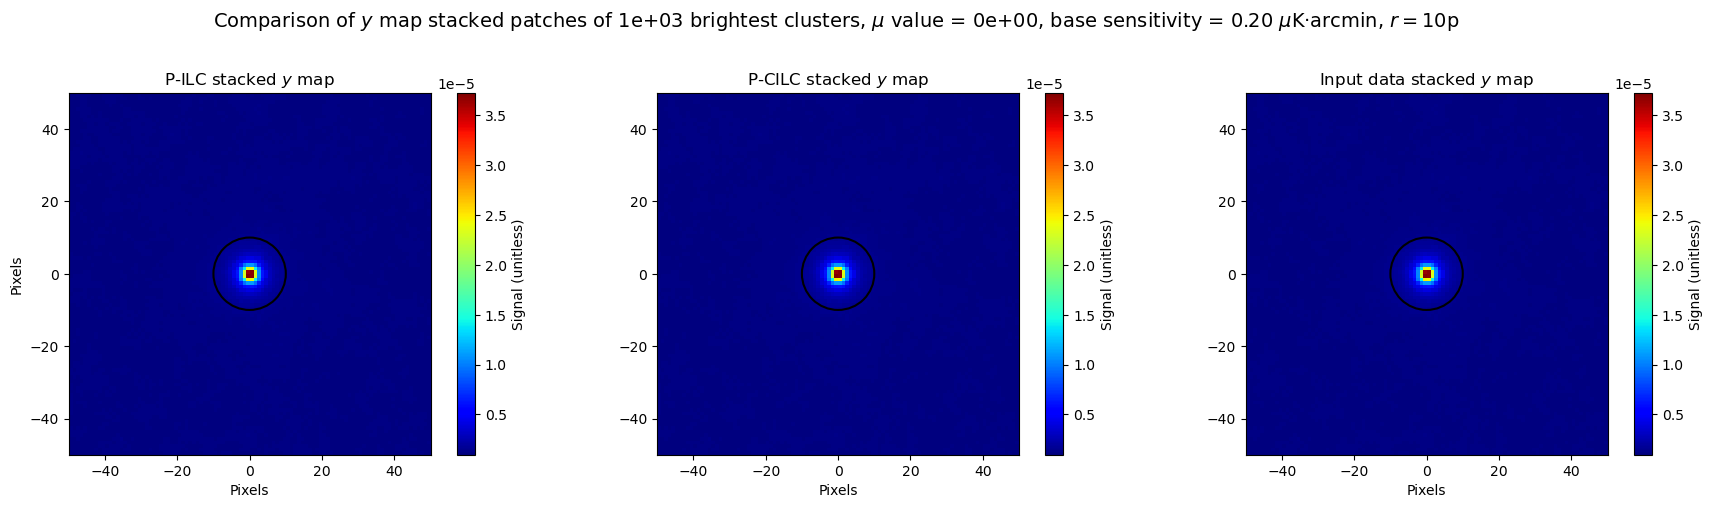

In [69]:
### PLOTTING THE 10^3 THREE y STACKED PATCHES TOGETHER FOR COMPARISON ###

plot_comparison_stacked_patches_y(
    stack_y_ilc_10e3,
    stack_y_cilc_10e3, 
    stack_y_real_10e3,
    n_clusters=1000, 
    mu=mu,
    base_sensitivity=base_sensitivity_uk_arcmin,
    map="$y$",
    filename="Comparison_Stacked_Patches_y"
)

In [ ]:
### PLOTTING THE 10^4 THREE y STACKED PATCHES TOGETHER FOR COMPARISON ###

plot_comparison_stacked_patches_y(
    stack_y_ilc_10e4,
    stack_y_cilc_10e4, 
    stack_y_real_10e4,
    n_clusters=1e+04, 
    mu=mu,
    base_sensitivity=base_sensitivity_uk_arcmin,
    map="$y$",
    filename="Comparison_Stacked_Patches_y"
)

In [ ]:
### PLOTTING THE 10^5 THREE y STACKED PATCHES TOGETHER FOR COMPARISON ###

plot_comparison_stacked_patches_y(
    stack_y_ilc_10e5,
    stack_y_cilc_10e5, 
    stack_y_real_10e5,
    n_clusters=100000, 
    mu=mu,
    base_sensitivity=base_sensitivity_uk_arcmin,
    map="$y$",
    filename="Comparison_Stacked_Patches_y"
)

In [70]:
def plot_comparison_stacked_patches_muy(stack_muy_ilc, stack_muy_cilc, stack_muy_real, n_clusters, mu, base_sensitivity, map, filename):
    """
    Plots three comparison stacked patches (Pixel ILC, Pixel CILC, and Input Data) 
    in a single row for side-by-side comparison.
    """
    maps = [stack_muy_ilc, stack_muy_cilc, stack_muy_real]
    titles = [r"P-ILC stacked $\mu y$ map", r"P-CILC stacked $\mu y$ map", r"Input data stacked $\mu y$ map"]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Define colorbar limits based on your provided params
    # Using your intermediate mu-y scale as an example
    v_min, v_max = -5e-9, 5e-9 

    for i, ax in enumerate(axes):
        # Calculate extents to center the pixels around (0,0)
        extent = [-maps[i].shape[1]//2, maps[i].shape[1]//2, -maps[i].shape[0]//2, maps[i].shape[0]//2]
        
        im = ax.imshow(maps[i], origin='lower', cmap='jet', extent=extent, vmin=v_min, vmax=v_max)
        
        # Add center marker
        #ax.plot(0, 0, marker='+', color='red', markersize=10, label='Center')
        
        ax.set_title(titles[i])
        ax.set_xlabel('Pixels')
        if i == 0:
            ax.set_ylabel('Pixels')

        # Paràmetres: (centre_x, centre_y), radi, color...
        radi_cercle = 10  # Pots ajustar aquest valor segons l'escala dels teus píxels
        cercle = patches.Circle((0, 0), radi_cercle, color='black', fill=False, linewidth=1.5, linestyle='-')
        ax.add_patch(cercle)
        
        # Format colorbar with scientific notation
        cbar = fig.colorbar(im, ax=ax, label='Signal (unitless)')
        cbar.formatter.set_powerlimits((0, 0))
        cbar.update_ticks()

        # Rename n_clusters to save it in the directory
        n_clusters_str = f"{n_clusters:.0e}"

    plt.suptitle(rf"Comparison of {map} map stacked patches of {n_clusters_str} brightest clusters, $\mu$ value = {mu:.0e}, base sensitivity = {base_sensitivity:.2f} $\mu$K·arcmin, $r = {radi_cercle}$p", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save the comparison plot
    plt.savefig(f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/Stacking/{n_clusters_str}/{filename}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

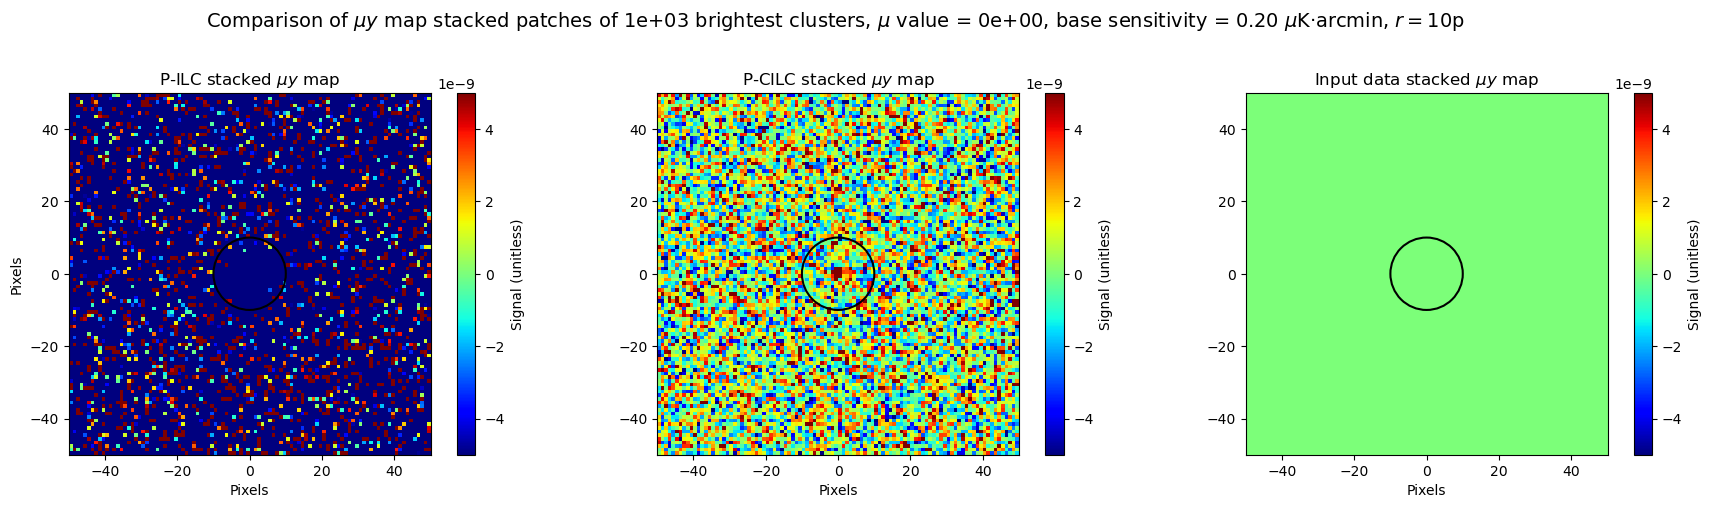

In [71]:
### PLOTTING THE 10^3 THREE mu_y STACKED PATCHES TOGETHER FOR COMPARISON ###

plot_comparison_stacked_patches_muy(
    stack_muy_ilc_10e3, 
    stack_muy_cilc_10e3, 
    stack_muy_real_10e3, 
    n_clusters=1000, 
    mu=mu,
    base_sensitivity=base_sensitivity_uk_arcmin,
    map=rf"$\mu y$",
    filename="Comparison_Stacked_Patches_muy"
)

In [ ]:
### PLOTTING THE 10^4 THREE mu_y STACKED PATCHES TOGETHER FOR COMPARISON ###

plot_comparison_stacked_patches_muy(
    stack_muy_ilc_10e4, 
    stack_muy_cilc_10e4, 
    stack_muy_real_10e4, 
    n_clusters=10000, 
    mu=mu,
    base_sensitivity=base_sensitivity_uk_arcmin,
    map=rf"$\mu y$",
    filename="Comparison_Stacked_Patches_muy"
)

In [ ]:
### PLOTTING THE 10^5 THREE mu_y STACKED PATCHES TOGETHER FOR COMPARISON ###

plot_comparison_stacked_patches_muy(
    stack_muy_ilc_10e5, 
    stack_muy_cilc_10e5, 
    stack_muy_real_10e5, 
    n_clusters=100000, 
    mu=mu,
    base_sensitivity=base_sensitivity_uk_arcmin,
    map=rf"$\mu y$",
    filename="Comparison_Stacked_Patches_muy"
)

## 6. T-T plot: $\mu y$ Vs. $y$ for $\mu$ extraction

### 6.1. Temperature-Temperature plot:
6.1.1. $\mu y$ Vs. $y$ --- $\mu$ value extraction

6.1.2. $y$ Vs. $y$

6.1.3. $\mu y$ Vs. $\mu y$

Linear regression for each case

### 6.1.1. $\mu y$ Vs. $y$ --- $\mu$ value extraction

### Full stacked map

In [ ]:
def plot_y_vs_muy(stack_y_ilc, stack_muy_ilc,
                    mu, base_sensitivity_uk_arcmin,
                    filename="TT_Plot.pdf",
                    xlabel=rf'Stacked $y$ real signal (unitless)',
                    ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                    title=rf'T-T Plot: processed $\mu y$ Vs. real $y$'):
    
    x_data = stack_y_ilc.flatten()
    y_data = stack_muy_ilc.flatten()

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    bias = np.abs(slope - mu)/std_err if std_err != 0 else 0.0

    # --- FIXED 2-DECIMAL SCIENTIFIC ROUNDING ---
    if slope != 0:
        common_exp = math.floor(math.log10(abs(slope)))
        val_scaled = slope / (10**common_exp)
        err_scaled = std_err / (10**common_exp)
        
        # If error is negligible (10,000x smaller), show as 0
        if (std_err / abs(slope)) < 1e-4:
            label_text = rf'$\mu = ({val_scaled:.2f} \pm 0.00) \times 10^{{{common_exp}}}$' + '\n' + rf'bias = {bias:.2f} $\sigma$'
        else:
            label_text = rf'$\mu = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$' + '\n' + rf'bias = {bias:.2f} $\sigma$'
    else:
        label_text = rf'$\mu = 0.00 \pm 0.00$' + '\n' + rf'bias = {bias:.2f} $\sigma$'

    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels', color='blue')
    
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', label=label_text)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/TT_plots/Full_map/{filename}.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

In [ ]:
### PLOTTING THE P-ILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_hat_ilc Vs. y_hat_muy_ilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy(stack_y_ilc, stack_muy_ilc,
                                                                mu, base_sensitivity_uk_arcmin,
                                                                filename="TT_Plot_PILC",
                                                                xlabel=rf'Stacked $y$ P-ILC signal (unitless)',
                                                                ylabel=rf'Stacked $\mu y$ P-ILC signal (unitless)',
                                                                title=rf'T-T Plot: P-ILC $\mu y$ Vs. P-ILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

In [ ]:
### PLOTTING THE P-CILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_hat_cilc Vs. y_hat_muy_cilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy(stack_y_cilc, stack_muy_cilc,
                                                                    mu, base_sensitivity_uk_arcmin,
                                                                    filename="TT_Plot_PCILC",
                                                                    xlabel=rf'Stacked $y$ P-CILC signal (unitless)',
                                                                    ylabel=rf'Stacked $\mu y$ P-CILC signal (unitless)',
                                                                    title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-CILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

In [ ]:
### PLOTTING THE INPUT T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_real Vs. muy_real --- TEST ON THE TT PLOT FUNCTION ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy(stack_y, stack_muy,
                                                                    mu, base_sensitivity_uk_arcmin,
                                                                    filename="TT_Plot_INPUT",
                                                                    xlabel=rf'Stacked $y$ input signal (unitless)',
                                                                    ylabel=rf'Stacked $\mu y$ input signal (unitless)',
                                                                    title=rf'T-T Plot: input $\mu y$ Vs. input $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

ODR

In [ ]:
def plot_y_vs_muy_odr(stack_y_ilc, stack_muy_ilc,
                    mu, base_sensitivity_uk_arcmin,
                    filename="TT_Plot.pdf",
                    xlabel=rf'Stacked $y$ real signal (unitless)',
                    ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                    title=rf'T-T Plot: processed $\mu y$ Vs. real $y$'):
    
    x_data = stack_y_ilc.flatten()
    y_data = stack_muy_ilc.flatten()

    # --- Use Orthogonal Distance Regression (ODR) ---
    # This accounts for errors in both x and y
    linear_model = odr.Model(lambda p, x: p[0] * x + p[1])
    data = odr.Data(x_data, y_data)
    # Use OLS results as starting guess
    ols_slope, ols_intercept, _, _, _ = stats.linregress(x_data, y_data)
    my_odr = odr.ODR(data, linear_model, beta0=[ols_slope, ols_intercept])
    output = my_odr.run()
    
    slope, intercept = output.beta
    # standard error of the slope from the covariance matrix
    std_err = output.sd_beta[0] 

    # Give the r and p values from the OLS for reference, but note that ODR doesn't directly provide these
    r_value = np.corrcoef(x_data, y_data)[0, 1]
    p_value = 2 * (1 - stats.norm.cdf(np.abs(r_value)))
    
    # Calculate bias using the more robust std_err
    bias = np.abs(slope - mu)/std_err if std_err != 0 else 0.0

    # --- FIXED 2-DECIMAL SCIENTIFIC ROUNDING ---
    if slope != 0:
        common_exp = math.floor(math.log10(abs(slope)))
        val_scaled = slope / (10**common_exp)
        err_scaled = std_err / (10**common_exp)
        
        if (std_err / abs(slope)) < 1e-4:
            label_text = rf'$\mu = ({val_scaled:.2f} \pm 0.00) \times 10^{{{common_exp}}}$' + '\n' + rf'bias = {bias:.2f} $\sigma$'
        else:
            label_text = rf'$\mu = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$' + '\n' + rf'bias = {bias:.2f} $\sigma$'
    else:
        label_text = rf'$\mu = 0.00 \pm 0.00$' + '\n' + rf'bias = {bias:.2f} $\sigma$'

    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.3, s=5, label='Cluster Pixels', color='blue', edgecolors='none')
    
    # Plot the regression line
    x_fit = np.array([np.min(x_data), np.max(x_data)])
    plt.plot(x_fit, slope * x_fit + intercept, color='red', lw=2, label=label_text)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    # Updated path logic to handle mu scientific notation in folder name
    folder_mu = f"{mu:.0e}".replace("+", "")
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{folder_mu}/TT_plots/Full_map/{filename}_ODR.pdf"
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err, bias

In [ ]:
### PLOTTING THE P-CILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_hat_cilc Vs. y_hat_muy_cilc ###

measured_mu, intercept, r_value, p_value, std_err, bias = plot_y_vs_muy_odr(stack_y_cilc, stack_muy_cilc,
                                                                    mu, base_sensitivity_uk_arcmin,
                                                                    filename="TT_Plot_PCILC",
                                                                    xlabel=rf'Stacked $y$ P-CILC signal (unitless)',
                                                                    ylabel=rf'Stacked $\mu y$ P-CILC signal (unitless)',
                                                                    title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-CILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

BOOTSTRAP

In [ ]:
def plot_y_vs_muy_fast_bootstrap(hp_map_y, hp_map_muy, cluster_coords, mu_true, 
                                 n_bootstrap=200, xsize=100, reso=1.5, filename="TT_Bootstrap_Fast.pdf"):
    """
    Optimized Bootstrap: Projects each cluster once, then resamples in memory.
    """
    import math
    n_clusters = len(cluster_coords)
    
    # 1. PRE-CALCULATE LIBRARY
    print(f"Pre-calculating library for {n_clusters} clusters...")
    library_y = []
    library_muy = []
    
    for lon, lat in cluster_coords:
        p_y = hp.gnomview(hp_map_y, rot=[lon, lat], reso=reso, xsize=xsize, 
                          return_projected_map=True, no_plot=True)
        p_muy = hp.gnomview(hp_map_muy, rot=[lon, lat], reso=reso, xsize=xsize, 
                            return_projected_map=True, no_plot=True)
        library_y.append(p_y)
        library_muy.append(p_muy)
        plt.close() # Crucial to prevent memory leaks from hidden figures
    
    library_y = np.array(library_y)
    library_muy = np.array(library_muy)

    # 2. BOOTSTRAP LOOP
    print(f"Running {n_bootstrap} bootstrap iterations...")
    bootstrap_slopes = []
    
    for _ in range(n_bootstrap):
        idx = np.random.randint(0, n_clusters, size=n_clusters)
        # Average the sampled patches, then flatten for regression
        boot_stack_y = np.mean(library_y[idx], axis=0).flatten()
        boot_stack_muy = np.mean(library_muy[idx], axis=0).flatten()
        
        res = stats.linregress(boot_stack_y, boot_stack_muy)
        bootstrap_slopes.append(res.slope)

    # 3. STATISTICS
    final_slope = np.mean(bootstrap_slopes)
    robust_std_err = np.std(bootstrap_slopes, ddof=1)
    
    # Avoid division by zero in bias if error is 0
    bias = np.abs(final_slope - mu_true) / robust_std_err if robust_std_err > 0 else 0.0

    # 4. PREPARE PLOT DATA
    # x_data and y_data are the pixels of the FULL average stack
    x_data = np.mean(library_y, axis=0).flatten()
    y_data = np.mean(library_muy, axis=0).flatten()
    
    # Get intercept from the full stack for the plot line
    res_full = stats.linregress(x_data, y_data)
    final_intercept = res_full.intercept

    # 5. FORMATTING LEGEND
    if final_slope != 0:
        common_exp = math.floor(math.log10(abs(final_slope)))
        val_scaled = final_slope / (10**common_exp)
        err_scaled = robust_std_err / (10**common_exp)
        label_text = (rf'$\mu = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$' + '\n' + 
                      rf'Bias = {bias:.2f} $\sigma$ (Bootstrap)')
    else:
        label_text = rf"$\mu = 0.00 \pm 0.00$"

    # 6. PLOTTING
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.3, s=5, color='blue', label='Full Stack Pixels')
    
    line_x = np.array([np.min(x_data), np.max(x_data)])
    plt.plot(line_x, final_slope * line_x + final_intercept, color='red', lw=2, label=label_text)

    plt.xlabel(rf'Stacked $y$ signal')
    plt.ylabel(rf'Stacked $\mu y$ signal')
    plt.title(rf'T-T Plot: Bootstrap ($\sigma$ from {n_bootstrap} iterations)')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Save logic
    folder_mu = rf"{mu_true:.0e}".replace("+", "")
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{folder_mu}/TT_plots/Full_map/{filename}_Fast_Bootstrap.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return final_slope, robust_std_err, bias

In [ ]:
### PLOTTING THE P-CILC T-T CORRELATION WITH fast BOOTSTRAP ERROR ESTIMATION --- y_hat_cilc Vs. y_hat_muy_cilc --- Full Map ###

final_slope, robust_std_err, bias = plot_y_vs_muy_fast_bootstrap(
    hp_map_y=y_hat_pixel_cilc,
    hp_map_muy=muy_hat_pixel_cilc,
    cluster_coords=cluster_coords,
    mu_true=mu,
    n_bootstrap=200,
    xsize=100,
    reso=1.5,
    filename="TT_Plot_PCILC"
)

### 10p radius cut --- 10e3 stacked patches

In [28]:
def plot_y_vs_muy_10p_radius(stack_y_ilc, stack_muy_ilc, mu, base_sensitivity_uk_arcmin, n_clusters,
                        filename="TT_Plot.pdf",
                        xlabel=rf'Stacked $y$ real signal (unitless)',
                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                        title=rf'T-T Plot: processed $\mu y$ Vs. real $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels'):
    
    # Rename n_clusters to save it in the directory
    n_clusters_str = f"{n_clusters:.0e}"

    # Flatten the 2D stacked patches into 1D arrays for scatter plotting and regression
    x_data = stack_y_ilc.flatten()
    y_data = stack_muy_ilc.flatten()

    # r = 10 pixel
    center = np.array(stack_y_ilc.shape) // 2
    y_indices, x_indices = np.indices(stack_y_ilc.shape)
    distances = np.sqrt((x_indices - center[1])**2 + (y_indices - center[0])**2)
    mask = distances <= 10  # Keep pixels within a 10 pixel radius
    x_data = x_data[mask.flatten()]
    y_data = y_data[mask.flatten()]

    # Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    bias = np.abs(slope - mu)/std_err if std_err != 0 else 0.0

    # --- FIXED 2-DECIMAL SCIENTIFIC ROUNDING ---
    if slope != 0:
        common_exp = math.floor(math.log10(abs(slope)))
        val_scaled = slope / (10**common_exp)
        err_scaled = std_err / (10**common_exp)
        
        # If error is negligible (10,000x smaller), show as 0
        if (std_err / abs(slope)) < 1e-4:
            label_text = rf'$\mu = ({val_scaled:.2f} \pm 0.00) \times 10^{{{common_exp}}}$' + '\n' + rf'bias = {bias:.2f} $\sigma$'
        else:
            label_text = rf'$\mu = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$' + '\n' + rf'bias = {bias:.2f} $\sigma$'
    else:
        label_text = rf'$\mu = 0.00 \pm 0.00$' + '\n' + rf'bias = {bias:.2f} $\sigma$'

    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels', color='blue')
    
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', label=label_text)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/TT_plots/10p/{n_clusters_str}/{filename}_10p.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

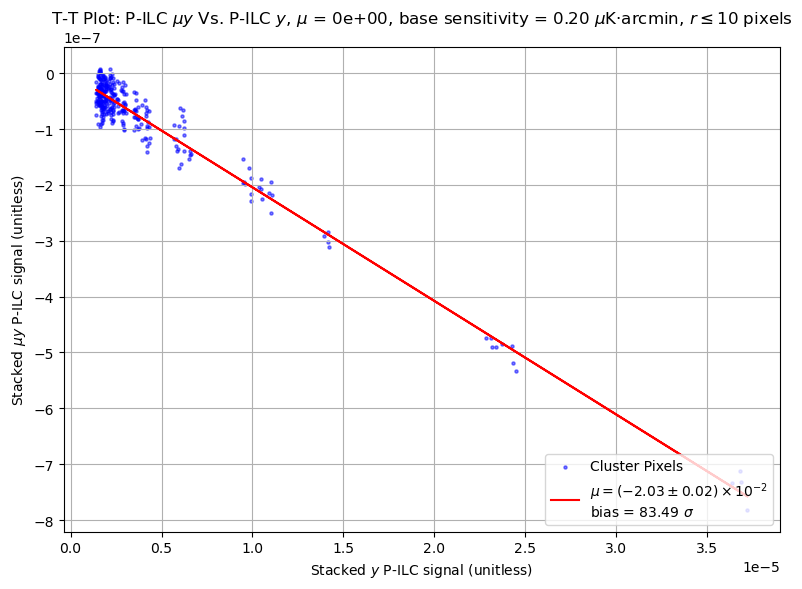

--- Statistics ---
y = -2.03e-02 * x + -1.14e-09
R-squared: 0.9568, p-value: 6.41e-217, std_err: 2.43e-04
----------------------
Measured mu = -2.03e-02
Input    mu = 0.00e+00


In [29]:
### PLOTTING THE P-ILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE FROM THE 10^3 STACKED PATCHES --- 10p radius --- y_hat_ilc Vs. y_hat_muy_ilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy_10p_radius(stack_y_ilc_10e3, stack_muy_ilc_10e3, mu, base_sensitivity_uk_arcmin, n_clusters=1000,
                                                                        filename="TT_Plot_PILC",
                                                                        xlabel=rf'Stacked $y$ P-ILC signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ P-ILC signal (unitless)',
                                                                        title=rf'T-T Plot: P-ILC $\mu y$ Vs. P-ILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

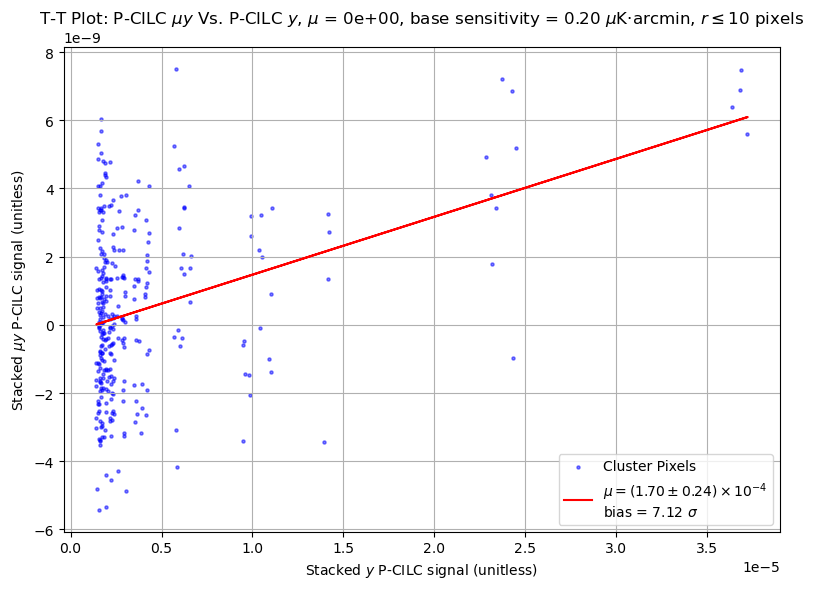

--- Statistics ---
y = 1.70e-04 * x + -2.27e-10
R-squared: 0.1387, p-value: 7.21e-12, std_err: 2.38e-05
----------------------
Measured mu = 1.70e-04
Input    mu = 0.00e+00


In [30]:
### PLOTTING THE P-CILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE FROM THE 10^3 STACKED PATCHES --- 10p radius --- y_hat_cilc Vs. y_hat_muy_cilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy_10p_radius(stack_y_cilc_10e3, stack_muy_cilc_10e3, mu, base_sensitivity_uk_arcmin, n_clusters=1000,
                                                                        filename="TT_Plot_PCILC",
                                                                        xlabel=rf'Stacked $y$ P-CILC signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ P-CILC signal (unitless)',
                                                                        title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-CILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

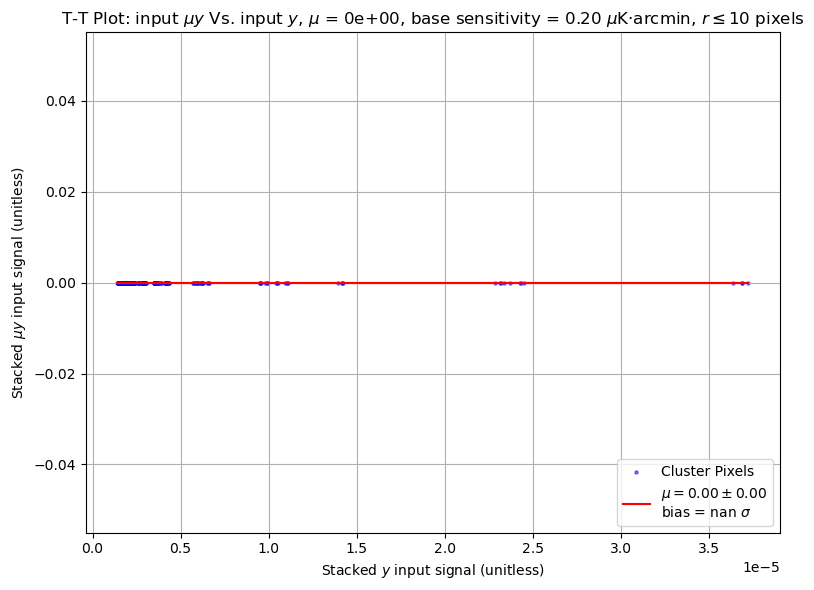

--- Statistics ---
y = 0.00e+00 * x + 0.00e+00
R-squared: nan, p-value: nan, std_err: nan
----------------------
Measured mu = 0.00e+00
Input    mu = 0.00e+00


In [34]:
### PLOTTING THE INPUT T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE FROM THE 10^3 STACKED PATCHES --- 10p radius --- y_real Vs. muy_real --- TEST ON THE TT PLOT FUNCTION ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy_10p_radius(stack_y_real_10e3, stack_muy_real_10e3, mu, base_sensitivity_uk_arcmin, n_clusters=1000,
                                                                        filename="TT_Plot_INPUT",
                                                                        xlabel=rf'Stacked $y$ input signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ input signal (unitless)',
                                                                        title=rf'T-T Plot: input $\mu y$ Vs. input $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

ODR

In [ ]:
def plot_y_vs_muy_10p_radius_odr(stack_y_ilc, stack_muy_ilc,
                                mu, base_sensitivity_uk_arcmin,
                                filename="TT_Plot.pdf",
                                xlabel=rf'Stacked $y$ real signal (unitless)',
                                ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                title=rf'T-T Plot: processed $\mu y$ Vs. real $y$'):
    
    x_data = stack_y_ilc.flatten()
    y_data = stack_muy_ilc.flatten()

    # r = 10 pixel
    center = np.array(stack_y_ilc.shape) // 2
    y_indices, x_indices = np.indices(stack_y_ilc.shape)
    distances = np.sqrt((x_indices - center[1])**2 + (y_indices - center[0])**2)
    mask = distances <= 10  # Keep pixels within a 10 pixel radius
    x_data = x_data[mask.flatten()]
    y_data = y_data[mask.flatten()]

    # --- Use Orthogonal Distance Regression (ODR) ---
    # This accounts for errors in both x and y
    linear_model = odr.Model(lambda p, x: p[0] * x + p[1])
    data = odr.Data(x_data, y_data)
    # Use OLS results as starting guess
    ols_slope, ols_intercept, _, _, _ = stats.linregress(x_data, y_data)
    my_odr = odr.ODR(data, linear_model, beta0=[ols_slope, ols_intercept])
    output = my_odr.run()
    
    slope, intercept = output.beta
    # standard error of the slope from the covariance matrix
    std_err = output.sd_beta[0] 

    # Give the r and p values from the OLS for reference, but note that ODR doesn't directly provide these
    r_value = np.corrcoef(x_data, y_data)[0, 1]
    p_value = 2 * (1 - stats.norm.cdf(np.abs(r_value)))
    
    # Calculate bias using the more robust std_err
    bias = np.abs(slope - mu)/std_err if std_err != 0 else 0.0

    # --- FIXED 2-DECIMAL SCIENTIFIC ROUNDING ---
    if slope != 0:
        common_exp = math.floor(math.log10(abs(slope)))
        val_scaled = slope / (10**common_exp)
        err_scaled = std_err / (10**common_exp)
        
        if (std_err / abs(slope)) < 1e-4:
            label_text = rf'$\mu = ({val_scaled:.2f} \pm 0.00) \times 10^{{{common_exp}}}$' + '\n' + rf'bias = {bias:.2f} $\sigma$'
        else:
            label_text = rf'$\mu = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$' + '\n' + rf'bias = {bias:.2f} $\sigma$'
    else:
        label_text = rf'$\mu = 0.00 \pm 0.00$' + '\n' + rf'bias = {bias:.2f} $\sigma$'

    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.3, s=5, label='Cluster Pixels', color='blue', edgecolors='none')
    
    # Plot the regression line
    x_fit = np.array([np.min(x_data), np.max(x_data)])
    plt.plot(x_fit, slope * x_fit + intercept, color='red', lw=2, label=label_text)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    # Updated path logic to handle mu scientific notation in folder name
    folder_mu = f"{mu:.0e}".replace("+", "")
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{folder_mu}/TT_plots/10p/{filename}_10p_ODR.pdf"
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err, bias

In [ ]:
### PLOTTING THE P-CILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_hat_cilc Vs. y_hat_muy_cilc ###

measured_mu, intercept, r_value, p_value, std_err, bias = plot_y_vs_muy_10p_radius_odr(stack_y_cilc, stack_muy_cilc,
                                                                                        mu, base_sensitivity_uk_arcmin,
                                                                                        filename="TT_Plot_PCILC",
                                                                                        xlabel=rf'Stacked $y$ P-CILC signal (unitless)',
                                                                                        ylabel=rf'Stacked $\mu y$ P-CILC signal (unitless)',
                                                                                        title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-CILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

BOOTSTRAP

In [ ]:
def plot_y_vs_muy_fast_bootstrap_10p_radius(hp_map_y, hp_map_muy, cluster_coords, mu_true, 
                                            n_bootstrap=200, xsize=100, reso=1.5, filename="TT_Bootstrap_Fast.pdf"):
    """
    Optimized Bootstrap: Projects each cluster once, then resamples in memory.
    """
    import math
    n_clusters = len(cluster_coords)
    
    # 1. PRE-CALCULATE LIBRARY
    print(f"Pre-calculating library for {n_clusters} clusters...")
    library_y = []
    library_muy = []
    
    for lon, lat in cluster_coords:
        p_y = hp.gnomview(hp_map_y, rot=[lon, lat], reso=reso, xsize=xsize, 
                          return_projected_map=True, no_plot=True)
        p_muy = hp.gnomview(hp_map_muy, rot=[lon, lat], reso=reso, xsize=xsize, 
                            return_projected_map=True, no_plot=True)
        library_y.append(p_y)
        library_muy.append(p_muy)
        plt.close() # Crucial to prevent memory leaks from hidden figures
    
    library_y = np.array(library_y)
    library_muy = np.array(library_muy)

    # 2. BOOTSTRAP LOOP
    print(f"Running {n_bootstrap} bootstrap iterations...")
    bootstrap_slopes = []
    
    for _ in range(n_bootstrap):
        idx = np.random.randint(0, n_clusters, size=n_clusters)
        # Average the sampled patches, then flatten for regression
        boot_stack_y = np.mean(library_y[idx], axis=0).flatten()
        boot_stack_muy = np.mean(library_muy[idx], axis=0).flatten()
        
        res = stats.linregress(boot_stack_y, boot_stack_muy)
        bootstrap_slopes.append(res.slope)

    # 3. STATISTICS
    final_slope = np.mean(bootstrap_slopes)
    robust_std_err = np.std(bootstrap_slopes, ddof=1)
    
    # Avoid division by zero in bias if error is 0
    bias = np.abs(final_slope - mu_true) / robust_std_err if robust_std_err > 0 else 0.0

    # 4. PREPARE PLOT DATA
    # x_data and y_data are the pixels of the FULL average stack
    x_data = np.mean(library_y, axis=0).flatten()
    y_data = np.mean(library_muy, axis=0).flatten()

    # r = 10 pixel
    center = np.array(stack_y_ilc.shape) // 2
    y_indices, x_indices = np.indices(stack_y_ilc.shape)
    distances = np.sqrt((x_indices - center[1])**2 + (y_indices - center[0])**2)
    mask = distances <= 10  # Keep pixels within a 10 pixel radius
    x_data = x_data[mask.flatten()]
    y_data = y_data[mask.flatten()]
    
    # Get intercept from the full stack for the plot line
    res_full = stats.linregress(x_data, y_data)
    final_intercept = res_full.intercept

    # 5. FORMATTING LEGEND
    if final_slope != 0:
        common_exp = math.floor(math.log10(abs(final_slope)))
        val_scaled = final_slope / (10**common_exp)
        err_scaled = robust_std_err / (10**common_exp)
        label_text = (rf'$\mu = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$' + '\n' + 
                      rf'Bias = {bias:.2f} $\sigma$ (Bootstrap)')
    else:
        label_text = rf"$\mu = 0.00 \pm 0.00$"

    # 6. PLOTTING
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.3, s=5, color='blue', label='Full Stack Pixels')
    
    line_x = np.array([np.min(x_data), np.max(x_data)])
    plt.plot(line_x, final_slope * line_x + final_intercept, color='red', lw=2, label=label_text)

    plt.xlabel(rf'Stacked $y$ signal')
    plt.ylabel(rf'Stacked $\mu y$ signal')
    plt.title(rf'T-T Plot: Bootstrap ($\sigma$ from {n_bootstrap} iterations)')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Save logic
    folder_mu = rf"{mu_true:.0e}".replace("+", "")
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{folder_mu}/TT_plots/Full_map/{filename}_10p_Fast_Bootstrap.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return final_slope, robust_std_err, bias

In [ ]:
### PLOTTING THE P-CILC T-T CORRELATION WITH fast BOOTSTRAP ERROR ESTIMATION --- y_hat_cilc Vs. y_hat_muy_cilc --- 10p radius ###

final_slope, robust_std_err, bias = plot_y_vs_muy_fast_bootstrap_10p_radius(
    hp_map_y=y_hat_pixel_cilc,
    hp_map_muy=muy_hat_pixel_cilc,
    cluster_coords=cluster_coords,
    mu_true=mu,
    n_bootstrap=200,
    xsize=100,
    reso=1.5,
    filename="TT_Plot_PCILC"
)

### 10p radius cut --- 10e4 stacked patches

In [ ]:
### PLOTTING THE P-CILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE FROM THE 10^4 STACKED PATCHES --- 10p radius --- y_hat_cilc Vs. y_hat_muy_cilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy_10p_radius(
    stack_y_cilc_10e4, stack_muy_cilc_10e4,
    mu, base_sensitivity_uk_arcmin,
    n_clusters=1e+04,
    filename="TT_Plot_PCILC",
    xlabel=rf'Stacked $y$ P-CILC signal (unitless)',
    ylabel=rf'Stacked $\mu y$ P-CILC signal (unitless)',
    title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-CILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels'
    )
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

### 10p radius cut --- 10e5 stacked patches

In [ ]:
### PLOTTING THE P-CILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE FROM THE 10^5 STACKED PATCHES --- 10p radius --- y_hat_cilc Vs. y_hat_muy_cilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy_10p_radius(
    stack_y_cilc_10e5, stack_muy_cilc_10e5,
    mu, base_sensitivity_uk_arcmin,
    filename="TT_Plot_PCILC",
    xlabel=rf'Stacked $y$ P-CILC signal (unitless)',
    ylabel=rf'Stacked $\mu y$ P-CILC signal (unitless)',
    title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-CILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels'
    )
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = {mu:.2e}")

### 6.1.2. $y$ Vs. $y$ --- Check whether there is a 1:1 correlation slope for $y$ between P-ILC and P-CILC

### Full stacked map

In [ ]:
def plot_y_ilc_vs_cilc(stack_y_ilc, stack_y_cilc,
                        mu, base_sensitivity_uk_arcmin,
                        filename="TT_Plot_Comparison.pdf",
                        xlabel=rf'Stacked $y$ P-ILC (unitless)',
                        ylabel=rf'Stacked $y$ P-CILC (unitless)',
                        title=rf'T-T Plot: P-CILC $y$ Vs. P-ILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin'):
    
    x_data = stack_y_ilc.flatten()
    y_data = stack_y_cilc.flatten()

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    # --- FIXED 2-DECIMAL SCIENTIFIC ROUNDING ---
    if slope != 0:
        common_exp = math.floor(math.log10(abs(slope)))
        val_scaled = slope / (10**common_exp)
        err_scaled = std_err / (10**common_exp)
        
        if (std_err / abs(slope)) < 1e-4:
            label_text = rf'$slope = ({val_scaled:.2f} \pm 0.00) \times 10^{{{common_exp}}}$'
        else:
            label_text = rf'$slope = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$'
    else:
        label_text = rf'$slope = 0.00 \pm 0.00$'

    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels', color='blue')
    
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', label=label_text)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/TT_plots/Full_map/{filename}.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

In [ ]:
### PLOTTING THE y P-ILC and P-CILC T-T CORRELATION --- y_hat_ilc Vs. y_hat_cilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_ilc_vs_cilc(stack_y_ilc, stack_y_cilc,
                                                                        mu, base_sensitivity_uk_arcmin,
                                                                        filename="TT_Plot_y_ILC_VS_CILC",
                                                                        xlabel=rf'Stacked $y$ P-ILC signal (unitless)',
                                                                        ylabel=rf'Stacked $y$ P-CILC signal (unitless)',
                                                                        title=rf'T-T Plot: P-ILC $y$ Vs. P-CILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin')
print("-----------------------")
print(f"----- Statistics -----")
print("-----------------------")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("-----------------------")
print(f"Slope = {measured_mu:.2e}")
print("-----------------------")
print(f"Input mu = {mu:.2e}")
print("-----------------------")
print("Full stacked map")
print("-----------------------")

### 10p radius cut

In [ ]:
def plot_y_ilc_vs_cilc_10p_radius(stack_y_ilc, stack_y_cilc,
                        mu, base_sensitivity_uk_arcmin,
                        filename="TT_Plot_Comparison.pdf",
                        xlabel=rf'Stacked $y$ P-ILC (unitless)',
                        ylabel=rf'Stacked $y$ P-CILC (unitless)',
                        title=rf'T-T Plot: P-CILC $y$ Vs. P-ILC $y$'):
    
    # Flatten the 2D stacked patches into 1D arrays for scatter plotting and regression
    x_data = stack_y_ilc.flatten()
    y_data = stack_y_cilc.flatten()

    # r = 10 pixel
    center = np.array(stack_y_ilc.shape) // 2
    y_indices, x_indices = np.indices(stack_y_ilc.shape)
    distances = np.sqrt((x_indices - center[1])**2 + (y_indices - center[0])**2)
    mask = distances <= 10  # Keep pixels within a 10 pixel radius
    x_data = x_data[mask.flatten()]
    y_data = y_data[mask.flatten()]

    # Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    # --- FIXED 2-DECIMAL SCIENTIFIC ROUNDING ---
    if slope != 0:
        common_exp = math.floor(math.log10(abs(slope)))
        val_scaled = slope / (10**common_exp)
        err_scaled = std_err / (10**common_exp)
        
        if (std_err / abs(slope)) < 1e-4:
            label_text = rf'$slope = ({val_scaled:.2f} \pm 0.00) \times 10^{{{common_exp}}}$'
        else:
            label_text = rf'$slope = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$'
    else:
        label_text = rf'$slope = 0.00 \pm 0.00$'

    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels', color='blue')
    
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', label=label_text)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/TT_plots/10p/{filename}_10p.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

In [ ]:
### PLOTTING THE y P-ILC and P-CILC T-T CORRELATION --- 10p radius --- y_hat_ilc Vs. y_hat_cilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_ilc_vs_cilc_10p_radius(stack_y_ilc, stack_y_cilc,
                                                                                mu, base_sensitivity_uk_arcmin,
                                                                                filename="TT_Plot_y_ILC_VS_CILC",
                                                                                xlabel=rf'Stacked $y$ P-ILC signal (unitless)',
                                                                                ylabel=rf'Stacked $y$ P-CILC signal (unitless)',
                                                                                title=rf'T-T Plot: P-ILC $y$ Vs. P-CILC $y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels')
print("-----------------------")
print(f"----- Statistics -----")
print("-----------------------")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("-----------------------")
print(f"Slope = {measured_mu:.2e}")
print("-----------------------")
print(f"Input mu = {mu:.2e}")
print("-----------------------")
print("10p radius cut")
print("-----------------------")

### 6.1.3. $\mu y$ Vs. $\mu y$ --- Check whether there is a 1:1 correlation slope for $\mu y$ between P-ILC and P-CILC

### Full stacked map

In [ ]:
def plot_muy_ilc_vs_cilc(stack_muy_ilc, stack_muy_cilc,
                        mu, base_sensitivity_uk_arcmin,
                        filename="TT_Plot_Comparison_muy.pdf",
                        xlabel=rf'Stacked $\mu y$ P-ILC (unitless)',
                        ylabel=rf'Stacked $\mu y$ P-CILC (unitless)',
                        title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-ILC $\mu y$'):
    
    # Flatten the 2D patches into 1D arrays for regression
    x_data = stack_muy_ilc.flatten()
    y_data = stack_muy_cilc.flatten()

    # Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    # --- FIXED 2-DECIMAL SCIENTIFIC ROUNDING ---
    if slope != 0:
        common_exp = math.floor(math.log10(abs(slope)))
        val_scaled = slope / (10**common_exp)
        err_scaled = std_err / (10**common_exp)
        
        # If error is negligible (10,000x smaller), show as 0.00
        if abs(slope) > 0 and (std_err / abs(slope)) < 1e-4:
            label_text = rf'$slope = ({val_scaled:.2f} \pm 0.00) \times 10^{{{common_exp}}}$'
        else:
            label_text = rf'$slope = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$'
    else:
        label_text = rf'$slope = 0.00 \pm 0.00$'

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels', color='blue')
    
    # Plot the regression line
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', label=label_text)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    
    # Save the plot with your specific local path
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/TT_plots/Full_map/{filename}"
    # Ensure filename includes .pdf if not provided in the function call
    if not save_path.endswith('.pdf'):
        save_path += '.pdf'
        
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

In [ ]:
### PLOTTING THE mu_y P-ILC and P-CILC T-T CORRELATION --- y_hat_muy_ilc Vs. y_hat_muy_cilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_muy_ilc_vs_cilc(stack_muy_ilc, stack_muy_cilc,
                                                                        mu, base_sensitivity_uk_arcmin,
                                                                        filename="TT_Plot_muy_ILC_VS_CILC",
                                                                        xlabel=rf'Stacked $\mu y$ P-ILC signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ P-CILC signal (unitless)',
                                                                        title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-ILC $\mu y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin')
print("-----------------------")
print(f"----- Statistics -----")
print("-----------------------")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("-----------------------")
print(f"Slope = {measured_mu:.2e}")
print("-----------------------")
print(f"Input mu = {mu:.2e}")
print("-----------------------")
print("Full stacked map")
print("-----------------------")

### 10p radius cut

In [ ]:
def plot_muy_ilc_vs_cilc_10p_radius(stack_muy_ilc, stack_muy_cilc,
                        mu, base_sensitivity_uk_arcmin,
                        filename="TT_Plot_Comparison_muy.pdf",
                        xlabel=rf'Stacked $\mu y$ P-ILC (unitless)',
                        ylabel=rf'Stacked $\mu y$ P-CILC (unitless)',
                        title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-ILC $\mu y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels'):
    
    # Flatten the 2D patches into 1D arrays for regression
    x_data = stack_muy_ilc.flatten()
    y_data = stack_muy_cilc.flatten()

    # r = 10 pixel
    center = np.array(stack_muy_ilc.shape) // 2
    y_indices, x_indices = np.indices(stack_muy_ilc.shape)
    distances = np.sqrt((x_indices - center[1])**2 + (y_indices - center[0])**2)
    mask = distances <= 10  # Keep pixels within a 10 pixel radius
    x_data = x_data[mask.flatten()]
    y_data = y_data[mask.flatten()]

    # Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    # --- FIXED 2-DECIMAL SCIENTIFIC ROUNDING ---
    if slope != 0:
        common_exp = math.floor(math.log10(abs(slope)))
        val_scaled = slope / (10**common_exp)
        err_scaled = std_err / (10**common_exp)
        
        # If error is negligible (10,000x smaller), show as 0.00
        if abs(slope) > 0 and (std_err / abs(slope)) < 1e-4:
            label_text = rf'$slope = ({val_scaled:.2f} \pm 0.00) \times 10^{{{common_exp}}}$'
        else:
            label_text = rf'$slope = ({val_scaled:.2f} \pm {err_scaled:.2f}) \times 10^{{{common_exp}}}$'
    else:
        label_text = rf'$slope = 0.00 \pm 0.00$'

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels', color='blue')
    
    # Plot the regression line
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', label=label_text)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    
    # Save the plot with your specific local path
    save_path = f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/TT_plots/10p/{filename}_10p.pdf"
    # Ensure filename includes .pdf if not provided in the function call
    if not save_path.endswith('.pdf'):
        save_path += '.pdf'
        
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

In [ ]:
### PLOTTING THE mu_y P-ILC and P-CILC T-T CORRELATION --- 10p radius --- y_hat_muy_ilc Vs. y_hat_muy_cilc ###

measured_mu, intercept, r_value, p_value, std_err = plot_muy_ilc_vs_cilc_10p_radius(stack_muy_ilc, stack_muy_cilc,
                                                                                    mu, base_sensitivity_uk_arcmin,
                                                                                    filename="TT_Plot_muy_ILC_VS_CILC",
                                                                                    xlabel=rf'Stacked $\mu y$ P-ILC signal (unitless)',
                                                                                    ylabel=rf'Stacked $\mu y$ P-CILC signal (unitless)',
                                                                                    title=rf'T-T Plot: P-CILC $\mu y$ Vs. P-ILC $\mu y$, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin, $r \leq 10$ pixels')
print("-----------------------")
print(f"----- Statistics -----")
print("-----------------------")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("-----------------------")
print(f"Slope = {measured_mu:.2e}")
print("-----------------------")
print(f"Input mu = {mu:.2e}")
print("-----------------------")
print("10p radius cut")
print("-----------------------")

## 7. Power spectrum comparison for $\mu$ extraction

In [ ]:
def compute_mu_from_spectra(muy_map, y_map, lmax=3000, label="Reconstructed"):
    """
    Computes and plots the ratio of cross-power spectrum to auto-power spectrum.
    """
    # 1. Compute Power Spectra

    # C_l^(muy * y)
    cl_cross = hp.anafast(muy_map, map2=y_map, lmax=lmax)
    
    # C_l^(y * y)
    cl_auto_y = hp.anafast(y_map, lmax=lmax)
    
    # 2. Compute the Ratio 
    # Avoid division by zero for l=0 and l=1
    ell = np.arange(len(cl_cross))
    ratio = np.zeros_like(cl_cross)
    mask = cl_auto_y > 0
    ratio[mask] = cl_cross[mask] / cl_auto_y[mask]
    
    return ell, ratio

In [ ]:
def compute_mu_from_spectra_binned(map_muy, map_y, lmax=3000, n_bins=40):
    """
    Computes the binned ratio of cross-power spectrum to auto-power spectrum.
    """
    # 1. Compute Raw Spectra
    cl_cross = hp.anafast(map_muy, map2=map_y, lmax=lmax)
    cl_auto_y = hp.anafast(map_y, lmax=lmax)
    ell = np.arange(len(cl_cross))
    
    # 2. Define Bins (starting from l=2 to avoid monopole/dipole)
    bins = np.linspace(2, lmax, n_bins + 1)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    # 3. Calculate Binned Spectra using np.histogram as a weighting tool
    # (Sum of weights in bin / count of elements in bin)
    cl_cross_binned = np.histogram(ell, bins=bins, weights=cl_cross)[0] / np.histogram(ell, bins=bins)[0]
    cl_auto_y_binned = np.histogram(ell, bins=bins, weights=cl_auto_y)[0] / np.histogram(ell, bins=bins)[0]
    
    ratio_binned = cl_cross_binned / cl_auto_y_binned
    
    return bin_centers, ratio_binned

### 7.1. Cross-power spectrum Vs. Auto-power spectrum

In [ ]:
### COMPUTE and save THE BINNED RATIOS --- FULL MAPS ---

# Input
l_bins_input, ratio_input = compute_mu_from_spectra_binned(muy_map, y_map)
np.savetxt(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Power_Spectrum/l_bins_ratio_input.txt", np.column_stack((l_bins_input, ratio_input)), header="l_bins_input ratio_input")

# CILC
l_bins_cilc, ratio_cilc = compute_mu_from_spectra_binned(muy_hat_pixel_cilc, y_hat_pixel_cilc)
np.savetxt(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/CILC_{mu:.0e}_maps/Power_Spectrum/l_bins_ratio_cilc.txt", np.column_stack((l_bins_cilc, ratio_cilc)), header="l_bins_cilc ratio_cilc")

In [ ]:
### PLOT THE BINNED SPECTRAL RATIO FOR THE FULL MAPS AND EXTRACT THE MU VALUE --- FULL MAPS ---

plt.figure(figsize=(10, 6))

# Plot binned results
plt.step(l_bins_input, ratio_input, where='mid', label="Input", alpha=0.5)
plt.plot(l_bins_cilc, ratio_cilc, 'ro-', label="CILC", lw=2)

# Legend labels with your requested 2-decimal notation
mu_input = mu
plt.axhline(mu_input, color='black', linestyle='--', label=rf'Input $\mu = {mu_input:.0e}$')

plt.xlabel(rf'Multipole $\ell$')
plt.ylabel(r'$C_{\ell}^{\hat{\mu y} \times \hat{y}} / C_{\ell}^{\hat{y} \times \hat{y}}$')
plt.title(rf'Binned spectral ratio for $\mu$ extraction, $\mu$ = {mu:.0e}, base sensitivity = {base_sensitivity_uk_arcmin:.2f} $\mu$K·arcmin')
#plt.ylim(0, mu_input * 2) 
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(f"/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/CILC_{mu:.0e}/Power_Spectra/Full_Map_Binned.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Cut at $\ell < 1000$ 

In [ ]:
def extract_mu_from_binned_ratio(l_bins, ratio_binned, mu_input=2e-4, l_max_cut=1000):
    """
    Extracts the mean mu value and bias from the already binned spectral ratio.
    """
    # 1. Slice the arrays based on your observation (l < 1000)
    # We ignore the first few bins if they are unstable (e.g., l < 10)
    mask = (l_bins > 10) & (l_bins < l_max_cut)
    
    selected_ratios = ratio_binned[mask]
    
    if len(selected_ratios) == 0:
        return 0, 0, 0

    # 2. Compute Statistics
    mu_extracted = np.mean(selected_ratios)
    # Standard Error of the Mean
    #mu_std_err = np.std(selected_ratios) / np.sqrt(len(selected_ratios)) # DOUBLE CHECK
    mu_std_err = np.std(selected_ratios) # DOUBLE CHECK
    
    # 3. Compute Bias in units of sigma
    bias_sigma = (mu_extracted - mu_input) / mu_std_err
    
    return mu_extracted, mu_std_err, bias_sigma

In [ ]:
### EXTRACT mu FROM THE FIRST l=1000 AND CALCULATE BIAS ###

mu_val, mu_err, bias = extract_mu_from_binned_ratio(l_bins_cilc, ratio_cilc, mu_input=mu)

print("--------------------------------------------")
print(f"--- Power Spectrum Extraction (l < 1000) ---")
print("--------------------------------------------")
print(f"Extracted mu: ({mu_val/1e-4:.2f} ± {mu_err/1e-4:.2f}) x 10^-4")
print(f"Bias: {bias:.2f} sigma")

### 7.2. Compute $\mu$ from the stacked patches via a Fast Fourier Transform (FFT)

In [ ]:
def compute_mu_from_patch_fft(patch_muy, patch_y, label="Reconstructed"):
    """
    Computes the ratio of the 2D cross-power spectrum to the auto-spectrum 
    for flat 2D patches.
    """
    # 1. 2D FFT of the patches
    fft_muy = np.fft.fft2(patch_muy)
    fft_y = np.fft.fft2(patch_y)
    
    # 2. Cross-spectrum (Real part of muy * conj(y))
    # This is the 2D equivalent of C_l^(muy x y)
    pk_cross = np.real(fft_muy * np.conj(fft_y))
    
    # 3. Auto-spectrum of y
    # This is the 2D equivalent of C_l^(y x y)
    pk_auto_y = np.real(fft_y * np.conj(fft_y))
    
    # 4. Global Ratio (Average over all spatial frequencies k)
    # This gives a single mu estimate from the entire patch
    mu_est = np.sum(pk_cross) / np.sum(pk_auto_y)

    # 5. Calculate the uncertainty --- Calculate sums (A and B)
    sum_cross = np.sum(pk_cross)
    sum_auto = np.sum(pk_auto_y)
    n_pixels = pk_cross.size # Total number of modes in the FFT

    # Variance of the SUM is N * Variance of pixels
    var_sum_cross = n_pixels * np.var(pk_cross)
    var_sum_auto = n_pixels * np.var(pk_auto_y)

    if sum_auto > 0:
        # Propagation: Delta_mu = mu * sqrt( (Delta_A/A)^2 + (Delta_B/B)^2 )
        std_err_fft = abs(mu_est) * np.sqrt((var_sum_cross / sum_cross**2) + (var_sum_auto / sum_auto**2))
    else:
        std_err_fft = 0.0
    
    return mu_est, std_err_fft

In [ ]:
# --- Print the FFT result for the stacked maps ---

mu_from_stack_input = compute_mu_from_patch_fft(stack_muy, stack_y, label="Input Stacked Patch")
mu_from_stack_cilc = compute_mu_from_patch_fft(stack_muy_cilc, stack_y_cilc, label="CILC Stacked Patch")
print("-----------------------")
print(rf"Input mu = {mu:.2e}")
print("-----------------------")
print(rf"Mu extracted from input stacked patches (FFT method): {mu_from_stack_input[0]:.2e} ± {mu_from_stack_input[1]:.2e}")
print(rf"Mu extracted from CILC stacked patches (FFT method): {mu_from_stack_cilc[0]:.2e} ± {mu_from_stack_cilc[1]:.2e}")

Apodized function applied so that the center has amplitude 1 and the corners amplitude 0

In [ ]:
def get_apodized_patch_window(xsize, alpha=0.5):
    """
    Creates a 2D Tukey (tapered cosine) window.
    alpha: Fraction of the window inside the cosine tapered region.
           0 is a square box, 1 is a Hann window.
    """
    # Create 1D windows for each axis
    w1d = windows.tukey(xsize, alpha=alpha)
    # Outer product to create 2D window
    w2d = np.outer(w1d, w1d)
    return w2d

In [ ]:
def compute_mu_from_patch_fft_apodized(patch_muy, patch_y, label="Reconstructed", alpha=0.5):
    win = get_apodized_patch_window(patch_muy.shape[0], alpha=alpha)
    
    # Apply window to both patches before FFT
    fft_muy = np.fft.fft2(patch_muy * win)
    fft_y = np.fft.fft2(patch_y * win)
    
    pk_cross = np.real(fft_muy * np.conj(fft_y))
    pk_auto_y = np.real(fft_y * np.conj(fft_y))
    
    mu_est = np.sum(pk_cross) / np.sum(pk_auto_y)
    
    # Uncertainty calculation (using the sum variance logic from before)
    n_pix = pk_cross.size
    var_sum_cross = n_pix * np.var(pk_cross)
    var_sum_auto = n_pix * np.var(pk_auto_y)
    std_err_fft = abs(mu_est) * np.sqrt((var_sum_cross / np.sum(pk_cross)**2) + 
                                       (var_sum_auto / np.sum(pk_auto_y)**2))
    
    return mu_est, std_err_fft

In [ ]:
# --- Print the FFT result for the stacked maps ---

mu_from_stack_input = compute_mu_from_patch_fft_apodized(stack_muy, stack_y, label="Input Stacked Patch")
mu_from_stack_cilc = compute_mu_from_patch_fft_apodized(stack_muy_cilc, stack_y_cilc, label="CILC Stacked Patch")
print("-----------------------")
print(rf"Input mu = {mu:.2e}")
print("-----------------------")
print(rf"Mu extracted from input stacked patches (FFT method): {mu_from_stack_input[0]:.2e} ± {mu_from_stack_input[1]:.2e}")
print(rf"Mu extracted from CILC stacked patches (FFT method): {mu_from_stack_cilc[0]:.2e} ± {mu_from_stack_cilc[1]:.2e}")

## 8. Aperture photometry for $\mu$ extraction